# Sistema de Inteligencia Comercial para el Análisis de Ventas y Optimización de Decisiones Estratégicas

### Trabajo Fin de Máster

**Máster Universitario en Analítica de Negocios y Datos Masivos**  
**Universidad CEU Fernando III**  
Curso Académico 2025–2026

---

**Autor:** Galo Efrén Abad Armas

**Tutor:** Agustín Walabonso Lara Romero

---

## Descripción del proyecto

El presente cuaderno documenta el proceso completo de análisis de datos desarrollado sobre el dataset de Olist, incluyendo las fases de comprensión de datos, preparación y transformación, análisis exploratorio, construcción de estructuras analíticas para Business Intelligence y aplicación de técnicas de aprendizaje automático para la segmentación de categorías de producto.

El objetivo principal es transformar datos transaccionales de comercio electrónico en información útil para apoyar la toma de decisiones estratégicas mediante herramientas de analítica de datos, Business Intelligence y Machine Learning.

---

# Índice del cuaderno

1. Comprensión y revisión inicial de los datos
2. Ingeniería de características (Feature Engineering)
3. Análisis Exploratorio de Datos (EDA)
4. Construcción del dataset para Power BI
5. Preparación de datos para modelos analíticos
6. Desarrollo y evaluación de modelos
   - 6.1 Modelos explorados
   - 6.2 Selección del modelo final
   - 6.3 Modelo de Clustering K-Means
7. Conclusiones analíticas

# 1. Comprensión y revisión inicial de los datos

En esta sección se realiza una exploración preliminar del dataset con el objetivo de comprender su estructura, identificar las entidades disponibles, analizar las relaciones entre tablas y verificar la calidad inicial de la información.

In [2]:
# Librerías

import sqlite3
import pandas as pd

# Conexión a la base de datos

conn = sqlite3.connect(r"C:\Gvlxo\Máster BI-BD\TFM\SQL\olist.db")

# Cargar la vista
df = pd.read_sql_query("SELECT * FROM vw_olist_fact_sales", conn)

# Primeras filas
df.head()

,order_id,order_item_id,product_id,seller_id,customer_id,customer_unique_id,price,freight_value,order_status,order_purchase_timestamp,...,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,product_category_name,product_category_name_english,product_category_final,customer_city,customer_state,seller_city,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,58.90,13.29,delivered,2017-09-13 08:59:02,...,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,cool_stuff,cool_stuff,cool_stuff,campos dos goytacazes,RJ,volta redonda,SP
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,239.90,19.93,delivered,2017-04-26 10:53:06,...,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15 00:00:00,pet_shop,pet_shop,pet_shop,santa fe do sul,SP,sao paulo,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,199.00,17.87,delivered,2018-01-14 14:33:31,...,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05 00:00:00,moveis_decoracao,furniture_decor,furniture_decor,para de minas,MG,borda da mata,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,12.99,12.79,delivered,2018-08-08 10:00:35,...,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20 00:00:00,perfumaria,perfumery,perfumery,atibaia,SP,franca,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,199.90,18.14,delivered,2017-02-04 13:57:51,...,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17 00:00:00,ferramentas_jardim,garden_tools,garden_tools,varzea paulista,SP,loanda,PR


In [3]:
df.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id', 'customer_id',
       'customer_unique_id', 'price', 'freight_value', 'order_status',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'product_category_name',
       'product_category_name_english', 'product_category_final',
       'customer_city', 'customer_state', 'seller_city', 'seller_state'],
      dtype='object')

In [4]:
df.shape

(112650, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 21 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       112650 non-null  object 
 1   order_item_id                  112650 non-null  int64  
 2   product_id                     112650 non-null  object 
 3   seller_id                      112650 non-null  object 
 4   customer_id                    112650 non-null  object 
 5   customer_unique_id             112650 non-null  object 
 6   price                          112650 non-null  float64
 7   freight_value                  112650 non-null  float64
 8   order_status                   112650 non-null  object 
 9   order_purchase_timestamp       112650 non-null  object 
 10  order_approved_at              112635 non-null  object 
 11  order_delivered_carrier_date   111456 non-null  object 
 12  order_delivered_customer_date 

# 2. Ingeniería de características (Feature Engineering)

Se generan nuevas variables a partir de la información original con el fin de enriquecer el análisis y capturar aspectos temporales, logísticos, geográficos y comerciales relevantes para el negocio.

In [6]:
# Conversión de variables temporales

date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col])

df[date_columns].dtypes

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [7]:
# Crear variables temporales 

df['year'] = df['order_purchase_timestamp'].dt.year
df['month'] = df ['order_purchase_timestamp'].dt.month

df[['order_purchase_timestamp', 'year', 'month']].head()

,order_purchase_timestamp,year,month
0,2017-09-13 08:59:02,2017,9
1,2017-04-26 10:53:06,2017,4
2,2018-01-14 14:33:31,2018,1
3,2018-08-08 10:00:35,2018,8
4,2017-02-04 13:57:51,2017,2


# 3. Análisis Exploratorio de Datos (EDA)

Se desarrolla un análisis descriptivo de los datos para identificar patrones de comportamiento, tendencias, distribuciones y relaciones entre variables de interés para la toma de decisiones.

In [ ]:
import matplotlib.pyplot as plt


<function matplotlib.pyplot.show(close=None, block=None)>

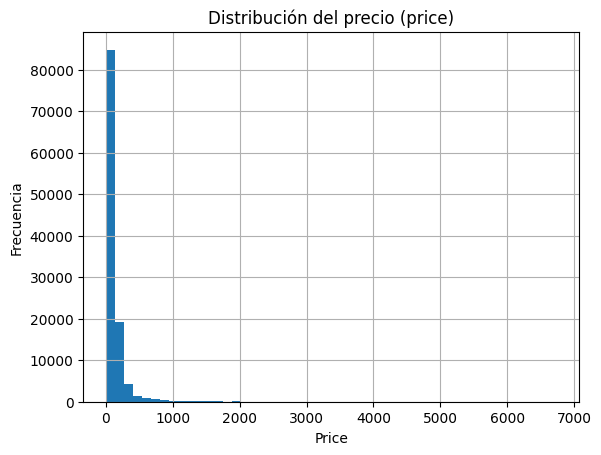

In [12]:
# Distribución del revenue

plt.figure
df['price'].hist(bins=50)
plt.title('Distribución del precio (price)')
plt.xlabel('Price')
plt.ylabel('Frecuencia')
plt.show

In [13]:
# Estadísticas descriptivas

df['price'].describe()

count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

In [14]:
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3 - q1

upper = q3 + 1.5 * iqr

outliers = df[df['price'] > upper]

print("Porcentaje outliers:", len(outliers) / len(df))
print("Revenue outliers:", outliers['price'].sum() / df['price'].sum())

Porcentaje outliers: 0.07480692410119841
Revenue outliers: 0.3560681803334795


In [15]:
#plt.figure(figsize=(8, 4))
#sns.boxplot(x=df["price"])
#plt.title("Price Boxplot")
#plt.show()

In [16]:
df['customer_unique_id'].nunique()

95420

In [17]:
# Revenue por pedido

order_revenue = df.groupby('order_id')['price'].sum()
order_revenue.describe()

count    98666.000000
mean       137.754076
std        210.645145
min          0.850000
25%         45.900000
50%         86.900000
75%        149.900000
max      13440.000000
Name: price, dtype: float64

<Axes: xlabel='price', ylabel='Count'>

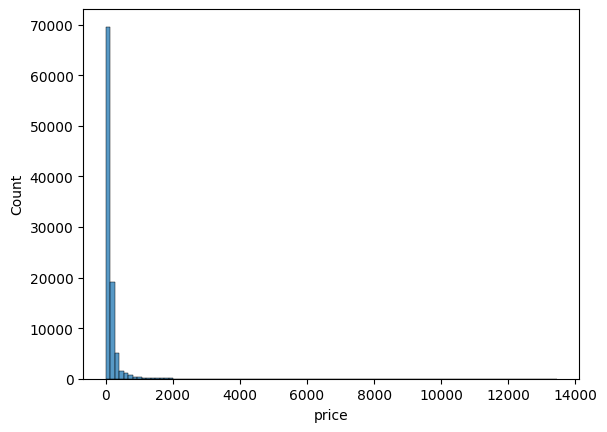

In [18]:
import seaborn as sns
sns.histplot(order_revenue, bins=100)

In [19]:
# Ticket promedio

order_revenue.mean()

np.float64(137.75407637889444)

In [20]:
# Distribución de pedidos por cliente

orders_per_customer = df.groupby('customer_unique_id')['order_id'].nunique()
orders_per_customer.describe()

count    95420.000000
mean         1.034018
std          0.211234
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         16.000000
Name: order_id, dtype: float64

In [21]:
# Revenue por categoría

category_revenue = (
    df.groupby('product_category_final')['price']
    .sum()
    .sort_values(ascending=False))

category_revenue.head(10)

product_category_final
health_beauty            1258681.34
watches_gifts            1205005.68
bed_bath_table           1036988.68
sports_leisure            988048.97
computers_accessories     911954.32
furniture_decor           729762.49
cool_stuff                635290.85
housewares                632248.66
auto                      592720.11
garden_tools              485256.46
Name: price, dtype: float64

In [22]:
# Participación porcentual por categoría

category_revenue_pct = (
    category_revenue/category_revenue.sum()*100
).round(2)

category_revenue_pct.head()

product_category_final
health_beauty            9.26
watches_gifts            8.87
bed_bath_table           7.63
sports_leisure           7.27
computers_accessories    6.71
Name: price, dtype: float64

In [23]:
# Tabla consolidada para categorías

category_summary = pd.DataFrame({
    'revenue': category_revenue,
    'pct_revenue': category_revenue_pct
})

category_summary.head(10)

,revenue,pct_revenue
product_category_final,,
health_beauty,1258681.34,9.26
watches_gifts,1205005.68,8.87
bed_bath_table,1036988.68,7.63
sports_leisure,988048.97,7.27
computers_accessories,911954.32,6.71
furniture_decor,729762.49,5.37
cool_stuff,635290.85,4.67
housewares,632248.66,4.65
auto,592720.11,4.36


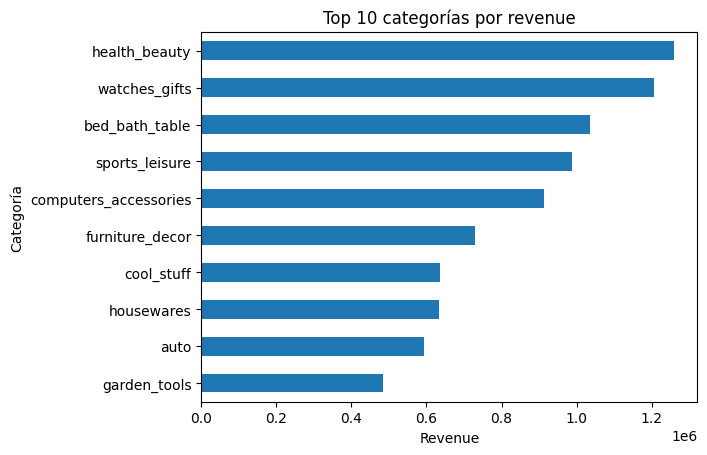

In [24]:
# Visualización top 10 categorías por revenue

top10_categories = category_summary.head(10)

plt.Figure(figsize=(10,6))
top10_categories['revenue'].sort_values().plot(kind='barh')
plt.title('Top 10 categorías por revenue')
plt.xlabel('Revenue')
plt.ylabel('Categoría')
plt.show()

In [25]:
# Pareto de categorías

pareto_categories = category_summary.copy()
pareto_categories['cum_revenue'] = pareto_categories['revenue'].cumsum()
pareto_categories['cum_pct_revenue'] = (
    pareto_categories['revenue'].cumsum() / pareto_categories['revenue'].sum() * 100
).round(2)

pareto_categories.head(15)

,revenue,pct_revenue,cum_revenue,cum_pct_revenue
product_category_final,,,,
health_beauty,1258681.34,9.26,1258681.34,9.26
watches_gifts,1205005.68,8.87,2463687.02,18.13
bed_bath_table,1036988.68,7.63,3500675.70,25.76
sports_leisure,988048.97,7.27,4488724.67,33.03
computers_accessories,911954.32,6.71,5400678.99,39.74
furniture_decor,729762.49,5.37,6130441.48,45.10
cool_stuff,635290.85,4.67,6765732.33,49.78
housewares,632248.66,4.65,7397980.99,54.43
auto,592720.11,4.36,7990701.10,58.79


In [26]:
# Cuántas categorías explican el 80% del revenue

categories_80 = (pareto_categories['cum_pct_revenue'] <=80).sum()

categories_80

np.int64(17)

In [27]:
# Conteo total de categorías

total_categories = df['product_category_final'].nunique()

total_categories

74

In [28]:
# Diferenciar revenue vs volumen por categoría

# Volumen de items por catgoría

category_items = (
    df.groupby('product_category_final')['order_item_id']
    .count()
    .sort_values(ascending=False)
)

category_items.head(10)

product_category_final
bed_bath_table           11115
health_beauty             9670
sports_leisure            8641
furniture_decor           8334
computers_accessories     7827
housewares                6964
watches_gifts             5991
telephony                 4545
garden_tools              4347
auto                      4235
Name: order_item_id, dtype: int64

In [29]:
# Pedidos únicos por categoría

category_orders = (
    df.groupby('product_category_final')['order_id']
    .nunique()
    .sort_values(ascending=False)
)

category_orders.head(10)

product_category_final
bed_bath_table           9417
health_beauty            8836
sports_leisure           7720
computers_accessories    6689
furniture_decor          6449
housewares               5884
watches_gifts            5624
telephony                4199
auto                     3897
toys                     3886
Name: order_id, dtype: int64

In [30]:
# Tabla Comparativa

category_compare = pd.DataFrame({
    'revenue': df.groupby('product_category_final')['price'].sum(),
    'items_sold': df.groupby('product_category_final')['order_item_id'].count(),
    'unique_orders': df.groupby('product_category_final')['order_id'].nunique()
}).sort_values(by='revenue', ascending=False)

category_compare.head(10)

,revenue,items_sold,unique_orders
product_category_final,,,
health_beauty,1258681.34,9670,8836
watches_gifts,1205005.68,5991,5624
bed_bath_table,1036988.68,11115,9417
sports_leisure,988048.97,8641,7720
computers_accessories,911954.32,7827,6689
furniture_decor,729762.49,8334,6449
cool_stuff,635290.85,3796,3632
housewares,632248.66,6964,5884
auto,592720.11,4235,3897


In [31]:
# Add ticket promedio por pedido en la categoría 

category_compare['avg_revenue_per_order'] = (
    category_compare['revenue'] / category_compare['unique_orders']
).round(2)

category_compare.head(10)

,revenue,items_sold,unique_orders,avg_revenue_per_order
product_category_final,,,,
health_beauty,1258681.34,9670,8836,142.45
watches_gifts,1205005.68,5991,5624,214.26
bed_bath_table,1036988.68,11115,9417,110.12
sports_leisure,988048.97,8641,7720,127.99
computers_accessories,911954.32,7827,6689,136.34
furniture_decor,729762.49,8334,6449,113.16
cool_stuff,635290.85,3796,3632,174.91
housewares,632248.66,6964,5884,107.45
auto,592720.11,4235,3897,152.10


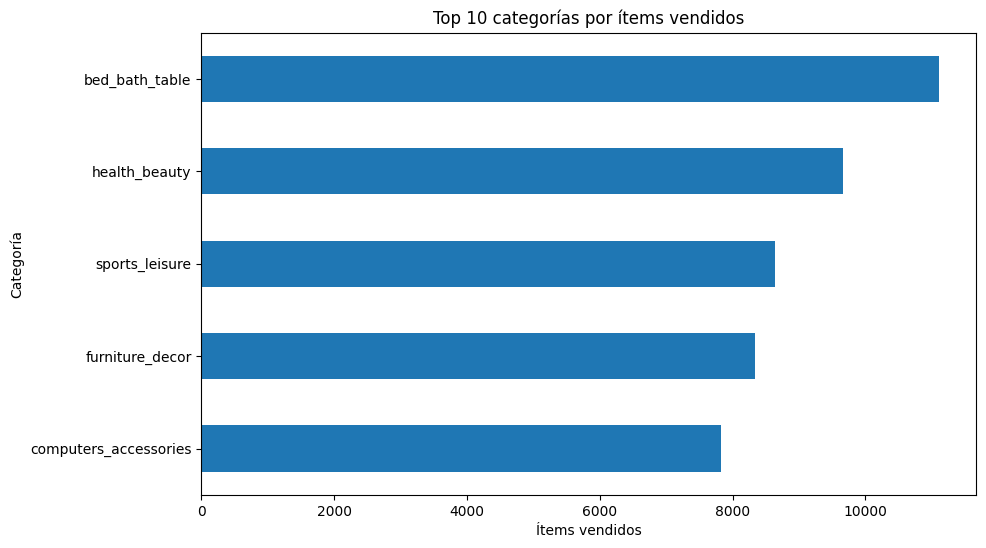

In [32]:
# Visualización comparativa

top10_items = category_items.head()

plt.figure(figsize=(10,6))
top10_items.sort_values().plot(kind='barh')
plt.title('Top 10 categorías por ítems vendidos')
plt.xlabel('Ítems vendidos')
plt.ylabel('Categoría')
plt.show()

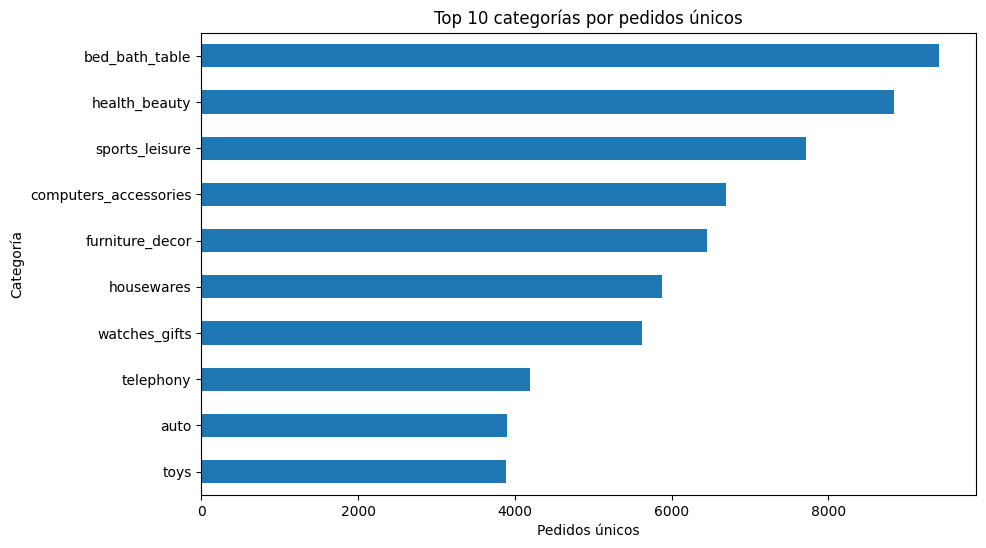

In [33]:
top10_orders = category_orders.head(10)

plt.figure(figsize=(10,6))
top10_orders.sort_values().plot(kind='barh')
plt.title('Top 10 categorías por pedidos únicos')
plt.xlabel('Pedidos únicos')
plt.ylabel('Categoría')
plt.show()

In [34]:
# Análisis temporal de revenue por mes

monthly_revenue = (
    df.groupby(['year', 'month'])['price']
      .sum()
      .reset_index()
)

monthly_revenue['year_month'] = (
    monthly_revenue['year'].astype(str) + '-' +
    monthly_revenue['month'].astype(str).str.zfill(2)
)

monthly_revenue

,year,month,price,year_month
0,2016,9,267.36,2016-09
1,2016,10,49507.66,2016-10
2,2016,12,10.90,2016-12
3,2017,1,120312.87,2017-01
4,2017,2,247303.02,2017-02
5,2017,3,374344.30,2017-03
6,2017,4,359927.23,2017-04
7,2017,5,506071.14,2017-05
8,2017,6,433038.60,2017-06
9,2017,7,498031.48,2017-07


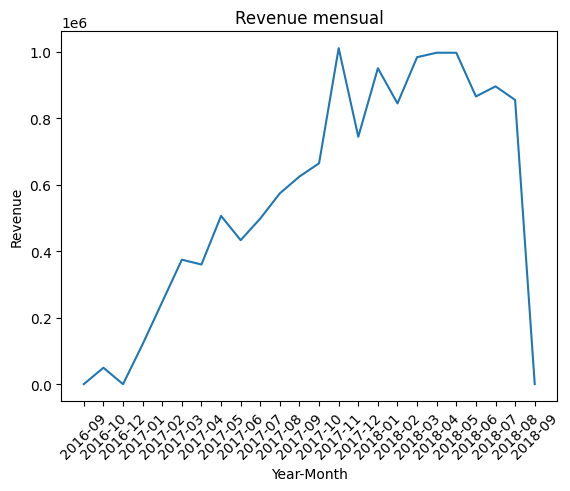

In [35]:
plt.Figure(figsize=(12,6))
plt.plot(monthly_revenue['year_month'], monthly_revenue ['price'])
plt.title('Revenue mensual')
plt.xlabel('Year-Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

In [36]:
# Pedidos únicos por mes

monthly_orders = (
    df.groupby(['year', 'month'])['order_id']
      .nunique()
      .reset_index()
)

monthly_orders['year_month'] = (
    monthly_orders['year'].astype(str) + '-' +
    monthly_orders['month'].astype(str).str.zfill(2)
)

monthly_orders

,year,month,order_id,year_month
0,2016,9,3,2016-09
1,2016,10,308,2016-10
2,2016,12,1,2016-12
3,2017,1,789,2017-01
4,2017,2,1733,2017-02
5,2017,3,2641,2017-03
6,2017,4,2391,2017-04
7,2017,5,3660,2017-05
8,2017,6,3217,2017-06
9,2017,7,3969,2017-07


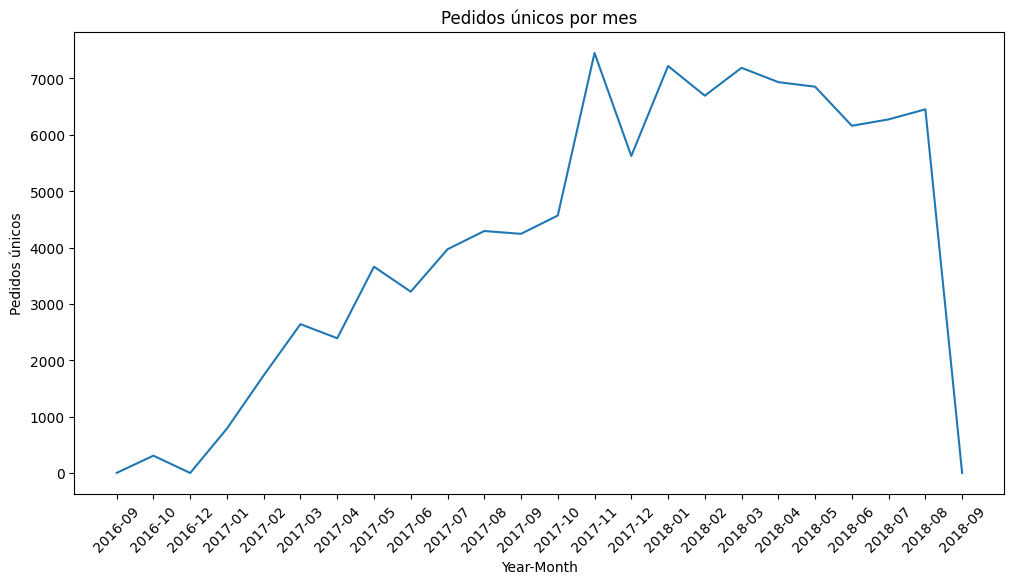

In [37]:
plt.figure(figsize=(12,6))
plt.plot(monthly_orders['year_month'], monthly_orders['order_id'])
plt.title('Pedidos únicos por mes')
plt.xlabel('Year-Month')
plt.ylabel('Pedidos únicos')
plt.xticks(rotation=45)
plt.show()

In [38]:
# Ticket promedio mensual

monthly_ticket = monthly_revenue.copy()
monthly_ticket = monthly_ticket.merge(
    monthly_orders[['year_month', 'order_id']],
    on='year_month',
    how='left'
)

monthly_ticket['avg_ticket'] = monthly_ticket['price'] / monthly_ticket['order_id']

monthly_ticket

,year,month,price,year_month,order_id,avg_ticket
0,2016,9,267.36,2016-09,3,89.120000
1,2016,10,49507.66,2016-10,308,160.739156
2,2016,12,10.90,2016-12,1,10.900000
3,2017,1,120312.87,2017-01,789,152.487795
4,2017,2,247303.02,2017-02,1733,142.702262
5,2017,3,374344.30,2017-03,2641,141.743393
6,2017,4,359927.23,2017-04,2391,150.534182
7,2017,5,506071.14,2017-05,3660,138.270803
8,2017,6,433038.60,2017-06,3217,134.609450
9,2017,7,498031.48,2017-07,3969,125.480343


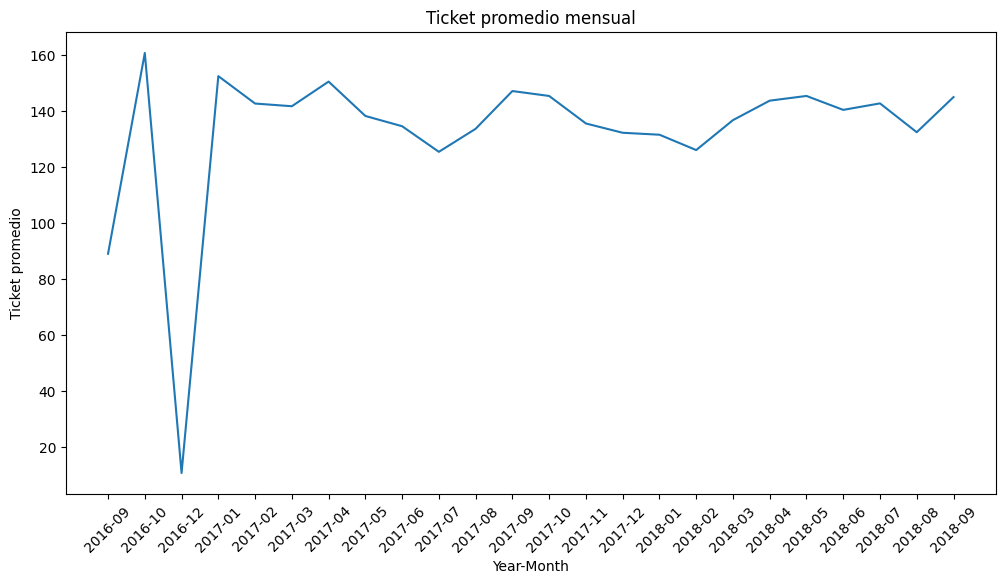

In [39]:
plt.figure(figsize=(12,6))
plt.plot(monthly_ticket['year_month'], monthly_ticket['avg_ticket'])
plt.title('Ticket promedio mensual')
plt.xlabel('Year-Month')
plt.ylabel('Ticket promedio')
plt.xticks(rotation=45)
plt.show()

In [40]:
# Análisis logístico: tiempo de entrega

# Delivery days

df['delivery_days'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days

In [41]:
# Delay days

df['delay_days'] = (
    df['order_delivered_customer_date'] - df['order_estimated_delivery_date']
).dt.days

In [42]:
# Estadísticas descriptivas de tiempos logísticos

df[['delivery_days','delay_days']].describe()

,delivery_days,delay_days
count,110196.000000,110196.000000
mean,12.007723,-12.030201
std,9.451455,10.160157
min,0.000000,-147.000000
25%,6.000000,-17.000000
50%,10.000000,-13.000000
75%,15.000000,-7.000000
max,209.000000,188.000000


In [ ]:
deciles = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Ejecutarel describe pasando el argumento percentiles
analisis_deciles = df[['delivery_days', 'delay_days']].describe(percentiles=deciles)

print(analisis_deciles)

       delivery_days     delay_days
count  110196.000000  110196.000000
mean       12.007723     -12.030201
std         9.451455      10.160157
min         0.000000    -147.000000
10%         4.000000     -22.000000
20%         5.000000     -19.000000
30%         7.000000     -16.000000
40%         8.000000     -14.000000
50%        10.000000     -13.000000
60%        12.000000     -10.000000
70%        14.000000      -8.000000
80%        17.000000      -6.000000
90%        22.000000      -2.000000
max       209.000000     188.000000


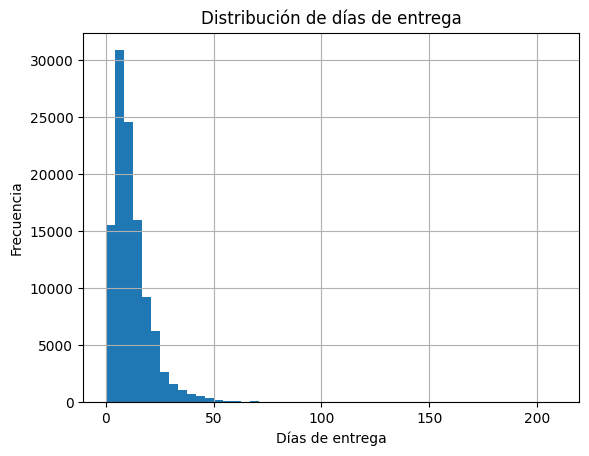

In [44]:
# Distribución de delivery_days

plt.Figure(figsize=(12,6))
df['delivery_days'].dropna().hist(bins=50)
plt.title('Distribución de días de entrega')
plt.xlabel('Días de entrega')
plt.ylabel('Frecuencia')
plt.show()

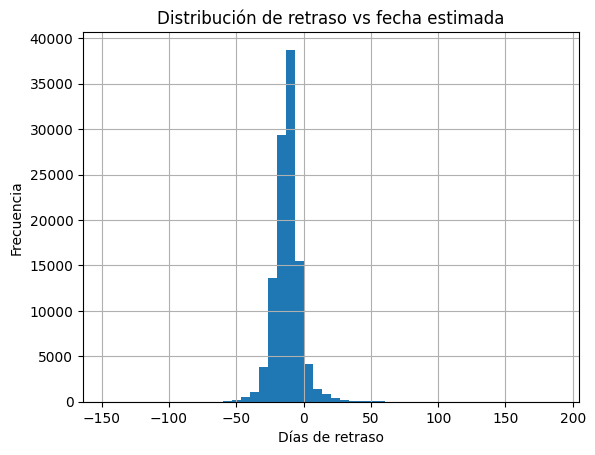

In [45]:
# Distribución de delay_days

plt.Figure(figsize=(12,6))
df['delay_days'].dropna().hist(bins=50)
plt.title('Distribución de retraso vs fecha estimada')
plt.xlabel('Días de retraso')
plt.ylabel('Frecuencia')
plt.show()

In [46]:
# Proporción de pedidos retrasados

late_orders_pct = (
    (df['delay_days'].dropna()>0).mean()*100
)

late_orders_pct

np.float64(6.592798286689172)

In [47]:
(df['delay_days']>0).sum()

np.int64(7265)

In [48]:
# Promedio de entrega por estado del pedido

df.groupby('order_status')['delivery_days'].agg(['count', 'mean', 'median'])

,count,mean,median
order_status,,,
approved,0,NaN,NaN
canceled,7,18.000000,10.0
delivered,110189,12.007342,10.0
invoiced,0,NaN,NaN
processing,0,NaN,NaN
shipped,0,NaN,NaN
unavailable,0,NaN,NaN


In [49]:
# Refinar el análisis logístico sobre pedidos realmente entregados

df_delivered = df[
    (df['order_status'] == 'delivered') &
    (df['delivery_days'].notna()) &
    (df['delay_days'].notna())
].copy()

df_delivered.shape

(110189, 25)

In [50]:
late_orders_pct_delivered = (
    (df_delivered['delay_days'] > 0).mean() * 100
)

late_orders_pct_delivered

np.float64(6.592309577181026)

In [51]:
df_delivered[['delivery_days', 'delay_days']].describe()

,delivery_days,delay_days
count,110189.000000,110189.000000
mean,12.007342,-12.029041
std,9.451153,10.158194
min,0.000000,-147.000000
25%,6.000000,-17.000000
50%,10.000000,-13.000000
75%,15.000000,-7.000000
max,209.000000,188.000000


In [52]:
# Relación entre logística y satisfacción

reviews_order = (
    pd.read_sql_query("""
        SELECT
            order_id,
            AVG(review_score) AS avg_review_score
        FROM olist_order_reviews_dataset
        GROUP BY order_id
    """, conn)
)

reviews_order.head()

,order_id,avg_review_score
0,00010242fe8c5a6d1ba2dd792cb16214,5.0
1,00018f77f2f0320c557190d7a144bdd3,4.0
2,000229ec398224ef6ca0657da4fc703e,5.0
3,00024acbcdf0a6daa1e931b038114c75,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0


In [53]:
# Unir reviews al dataset de entregado

df_log_reviews = df_delivered.merge(
    reviews_order,
    on='order_id',
    how='left'
)

df_log_reviews[['order_id', 'delay_days', 'avg_review_score']].head()

,order_id,delay_days,avg_review_score
0,00010242fe8c5a6d1ba2dd792cb16214,-9.0,5.0
1,00018f77f2f0320c557190d7a144bdd3,-3.0,4.0
2,000229ec398224ef6ca0657da4fc703e,-14.0,5.0
3,00024acbcdf0a6daa1e931b038114c75,-6.0,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,-16.0,5.0


In [54]:
# % de pedidos que tienen score

df_log_reviews['avg_review_score'].notna().mean()*100

np.float64(99.24947136284021)

In [55]:
# Comparar score promedio entre pedidos retrasados y no retrasados

# crear métrica de retraso

df_log_reviews['is_late'] = df_log_reviews['delay_days']>0

# Promedio de score por grupo

df_log_reviews.groupby('is_late')['avg_review_score'].agg(['count', 'mean', 'median'])


,count,mean,median
is_late,,,
False,102279,4.208378,5.0
True,7083,2.257306,1.0


In [56]:
# Score promedio por tramos de retraso

df_log_reviews['delay_bucket'] = pd.cut(
    df_log_reviews['delay_days'],
    bins=[-200, -15, -7, -1, 0, 3, 7, 15, 200],
    labels=[
        'mucho antes',
        'antes',
        'ligeramente antes',
        'en fecha',
        'retraso leve',
        'retraso moderado',
        'retraso alto',
        'retraso extremo'
    ]
)

df_log_reviews.groupby('delay_bucket')['avg_review_score'].agg(['count', 'mean']).sort_index()

C:\Users\galoa\AppData\Local\Temp\ipykernel_11928\4182140734.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_log_reviews.groupby('delay_bucket')['avg_review_score'].agg(['count', 'mean']).sort_index()


,count,mean
delay_bucket,,
mucho antes,40254,4.219494
antes,46604,4.231464
ligeramente antes,13985,4.122167
en fecha,1436,3.987117
retraso leve,2088,3.230843
retraso moderado,1943,2.089810
retraso alto,1759,1.684480
retraso extremo,1293,1.716164


In [57]:
customer_state = (
    df.groupby('customer_state')['customer_unique_id']
    .nunique()
    .sort_values(ascending=False)
)

customer_state.head(10)


customer_state
SP    39981
RJ    12303
MG    11178
RS     5249
PR     4840
SC     3513
BA     3257
DF     2062
ES     1956
GO     1942
Name: customer_unique_id, dtype: int64

In [58]:
state_map = {
    'SP': 'São Paulo',
    'RJ': 'Rio de Janeiro',
    'MG': 'Minas Gerais',
    'RS': 'Rio Grande do Sul',
    'PR': 'Paraná',
    'SC': 'Santa Catarina',
    'BA': 'Bahia',
    'DF': 'Distrito Federal',
    'ES': 'Espírito Santo',
    'GO': 'Goiás',
    'PE': 'Pernambuco',
    'CE': 'Ceará',
    'PA': 'Pará',
    'MT': 'Mato Grosso',
    'MA': 'Maranhão',
    'MS': 'Mato Grosso do Sul',
    'PB': 'Paraíba',
    'PI': 'Piauí',
    'RN': 'Rio Grande do Norte',
    'AL': 'Alagoas',
    'SE': 'Sergipe',
    'TO': 'Tocantins',
    'RO': 'Rondônia',
    'AM': 'Amazonas',
    'AC': 'Acre',
    'AP': 'Aapá',
    'RR': 'Roraima'
}

# Aplicar el mapeo al DataFrame
df['customer_state_full'] = df['customer_state'].map(state_map)

In [59]:
# Reutilizando el diccionario state_map anterior
df['seller_state_full'] = df['seller_state'].map(state_map)

In [61]:
customer_state = (
    df.groupby('customer_state_full')['customer_unique_id']
    .nunique()
    .sort_values(ascending=False)
)

customer_state.head(10)


customer_state_full
São Paulo            39981
Rio de Janeiro       12303
Minas Gerais         11178
Rio Grande do Sul     5249
Paraná                4840
Santa Catarina        3513
Bahia                 3257
Distrito Federal      2062
Espírito Santo        1956
Goiás                 1942
Name: customer_unique_id, dtype: int64

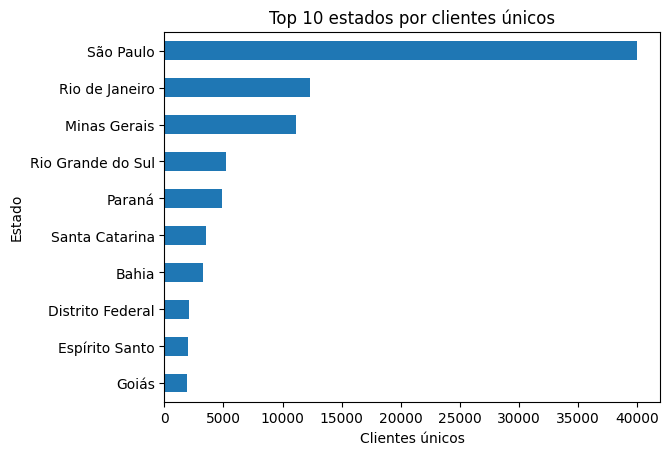

In [62]:
plt.Figure(figsize=(12,6))
customer_state.head(10).sort_values().plot(kind='barh')
plt.title('Top 10 estados por clientes únicos')
plt.xlabel('Clientes únicos')
plt.ylabel('Estado')
plt.show()

In [63]:
# Pedidos por estado del cliente

orders_state = (
    df.groupby('customer_state_full')['order_id']
    .nunique()
    .sort_values(ascending=False)
)

orders_state.head(10)

customer_state_full
São Paulo            41375
Rio de Janeiro       12762
Minas Gerais         11544
Rio Grande do Sul     5432
Paraná                4998
Santa Catarina        3612
Bahia                 3358
Distrito Federal      2125
Espírito Santo        2025
Goiás                 2007
Name: order_id, dtype: int64

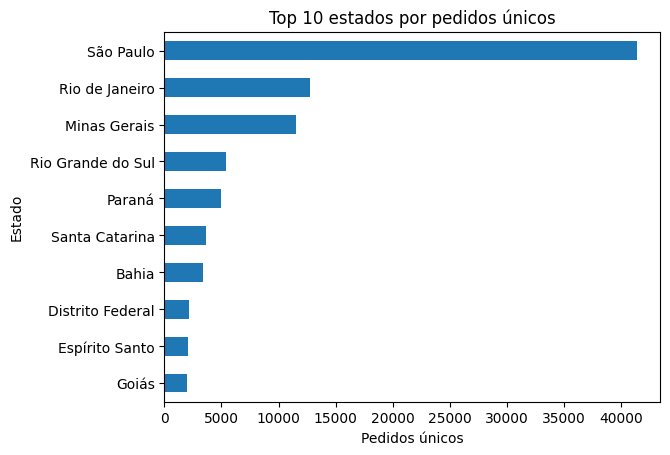

In [64]:
plt.Figure(figsize=(12,6))
orders_state.head(10).sort_values().plot(kind='barh')
plt.title('Top 10 estados por pedidos únicos')
plt.xlabel('Pedidos únicos')
plt.ylabel('Estado')
plt.show()


In [65]:
# Revenue por estado del cliente

revenue_state = (
    df.groupby('customer_state_full')['price']
    .sum()
    .sort_values(ascending=False)
)

revenue_state.head(10)

customer_state_full
São Paulo            5202955.05
Rio de Janeiro       1824092.67
Minas Gerais         1585308.03
Rio Grande do Sul     750304.02
Paraná                683083.76
Santa Catarina        520553.34
Bahia                 511349.99
Distrito Federal      302603.94
Goiás                 294591.95
Espírito Santo        275037.31
Name: price, dtype: float64

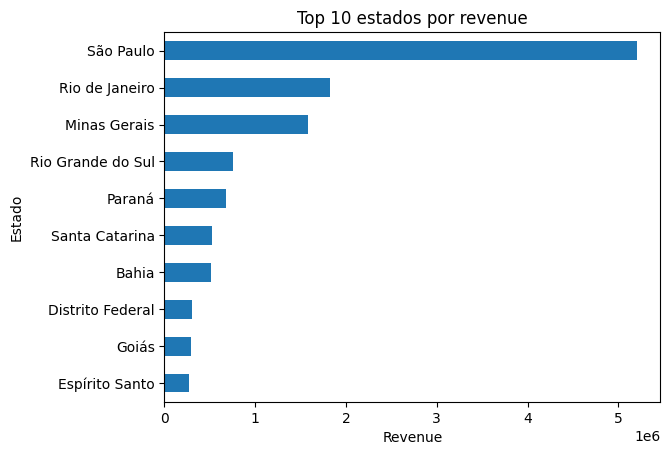

In [66]:
plt.Figure(figsize=(12,6))
revenue_state.head(10).sort_values().plot(kind='barh')
plt.title('Top 10 estados por revenue')
plt.xlabel('Revenue')
plt.ylabel('Estado')
plt.show()


In [67]:
# Tabla comparativa geográfica

geo_summary = pd.DataFrame({
    'customers_unique': df.groupby('customer_state_full')['customer_unique_id'].nunique(),
    'orders_unique': df.groupby('customer_state_full')['order_id'].nunique(),
    'revenue': df.groupby('customer_state_full')['price'].sum()
}).sort_values(by='revenue', ascending=False)

geo_summary.head(10)

,customers_unique,orders_unique,revenue
customer_state_full,,,
São Paulo,39981,41375,5202955.05
Rio de Janeiro,12303,12762,1824092.67
Minas Gerais,11178,11544,1585308.03
Rio Grande do Sul,5249,5432,750304.02
Paraná,4840,4998,683083.76
Santa Catarina,3513,3612,520553.34
Bahia,3257,3358,511349.99
Distrito Federal,2062,2125,302603.94
Goiás,1942,2007,294591.95


In [68]:
# Ticket promedio por estado

geo_summary['avg_revenue_per_order'] = (
    geo_summary['revenue']/geo_summary['orders_unique']
).round(2)

geo_summary.head(10)

,customers_unique,orders_unique,revenue,avg_revenue_per_order
customer_state_full,,,,
São Paulo,39981,41375,5202955.05,125.75
Rio de Janeiro,12303,12762,1824092.67,142.93
Minas Gerais,11178,11544,1585308.03,137.33
Rio Grande do Sul,5249,5432,750304.02,138.13
Paraná,4840,4998,683083.76,136.67
Santa Catarina,3513,3612,520553.34,144.12
Bahia,3257,3358,511349.99,152.28
Distrito Federal,2062,2125,302603.94,142.40
Goiás,1942,2007,294591.95,146.78


In [69]:
# Análisis geográfico de oferta: sellers por estado

sellers_state = (
    df.groupby('seller_state_full')['seller_id']
    .nunique()
    .sort_values(ascending=False)
)

sellers_state.head(10)

seller_state_full
São Paulo            1849
Paraná                349
Minas Gerais          244
Santa Catarina        190
Rio de Janeiro        171
Rio Grande do Sul     129
Goiás                  40
Distrito Federal       30
Espírito Santo         23
Bahia                  19
Name: seller_id, dtype: int64

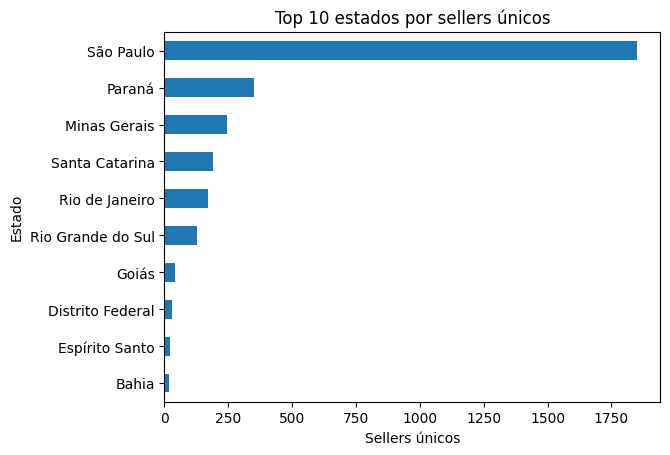

In [70]:
plt.Figure(figsize=(12,6))
sellers_state.head(10).sort_values().plot(kind='barh')
plt.title('Top 10 estados por sellers únicos')
plt.xlabel('Sellers únicos')
plt.ylabel('Estado')
plt.show()

In [71]:
# Revenue asociado a sellers por estado

revenue_sellers_state = (
    df.groupby('seller_state_full')['price']
    .sum()
    .sort_values(ascending=False)
)

revenue_sellers_state.head(10)

seller_state_full
São Paulo            8753396.21
Paraná               1261887.21
Minas Gerais         1011564.74
Rio de Janeiro        843984.22
Santa Catarina        632426.07
Rio Grande do Sul     378559.54
Bahia                 285561.56
Distrito Federal       97749.48
Pernambuco             91493.85
Goiás                  66399.21
Name: price, dtype: float64

<Axes: ylabel='seller_state_full'>

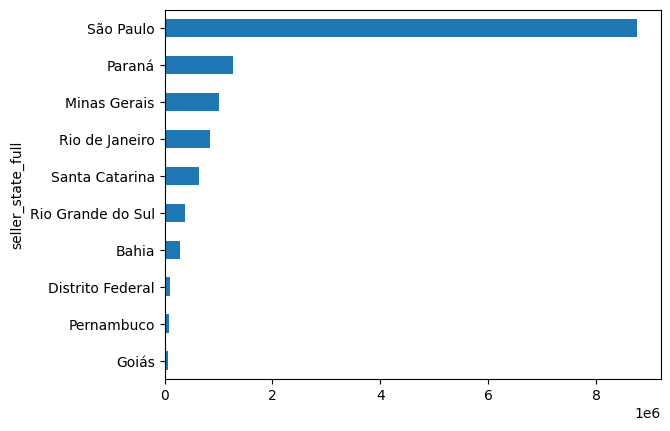

In [72]:
plt.Figure(figsize=(12,6))
revenue_sellers_state.head(10).sort_values().plot(kind='barh')

In [73]:
# Tabla comparativa de oferta

seller_geo_summary = pd.DataFrame({
    'sellers_unique': df.groupby('seller_state_full')['seller_id'].nunique(),
    'revenue': df.groupby('seller_state_full')['price'].sum()
}).sort_values(by='revenue', ascending=False)

seller_geo_summary.head(10)

,sellers_unique,revenue
seller_state_full,,
São Paulo,1849,8753396.21
Paraná,349,1261887.21
Minas Gerais,244,1011564.74
Rio de Janeiro,171,843984.22
Santa Catarina,190,632426.07
Rio Grande do Sul,129,378559.54
Bahia,19,285561.56
Distrito Federal,30,97749.48
Pernambuco,9,91493.85


In [74]:
# Comparación básica demanda vs oferta

demand_supply_compare = pd.DataFrame({
    'customers_unique': df.groupby('customer_state_full')['customer_unique_id'].nunique(),
    'orders_unique': df.groupby('customer_state_full')['order_id'].nunique(),
    'customer_revenue': df.groupby('customer_state_full')['price'].sum(),
    'sellers_unique': df.groupby('seller_state_full')['seller_id'].nunique(),
    'seller_revenue': df.groupby('seller_state_full')['price'].sum()
}).fillna(0)

demand_supply_compare.sort_values('orders_unique', ascending= False).head(15)

,customers_unique,orders_unique,customer_revenue,sellers_unique,seller_revenue
São Paulo,39981,41375,5202955.05,1849.0,8753396.21
Rio de Janeiro,12303,12762,1824092.67,171.0,843984.22
Minas Gerais,11178,11544,1585308.03,244.0,1011564.74
Rio Grande do Sul,5249,5432,750304.02,129.0,378559.54
Paraná,4840,4998,683083.76,349.0,1261887.21
Santa Catarina,3513,3612,520553.34,190.0,632426.07
Bahia,3257,3358,511349.99,19.0,285561.56
Distrito Federal,2062,2125,302603.94,30.0,97749.48
Espírito Santo,1956,2025,275037.31,23.0,47689.61
Goiás,1942,2007,294591.95,40.0,66399.21


In [75]:
df.isnull().sum()

order_id                            0
order_item_id                       0
product_id                          0
seller_id                           0
customer_id                         0
customer_unique_id                  0
price                               0
freight_value                       0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1194
order_delivered_customer_date    2454
order_estimated_delivery_date       0
product_category_name            1603
product_category_name_english    1627
product_category_final              0
customer_city                       0
customer_state                      0
seller_city                         0
seller_state                        0
year                                0
month                               0
delivery_days                    2454
delay_days                       2454
customer_state_full                 0
seller_state

In [76]:
df.duplicated().sum()

np.int64(0)

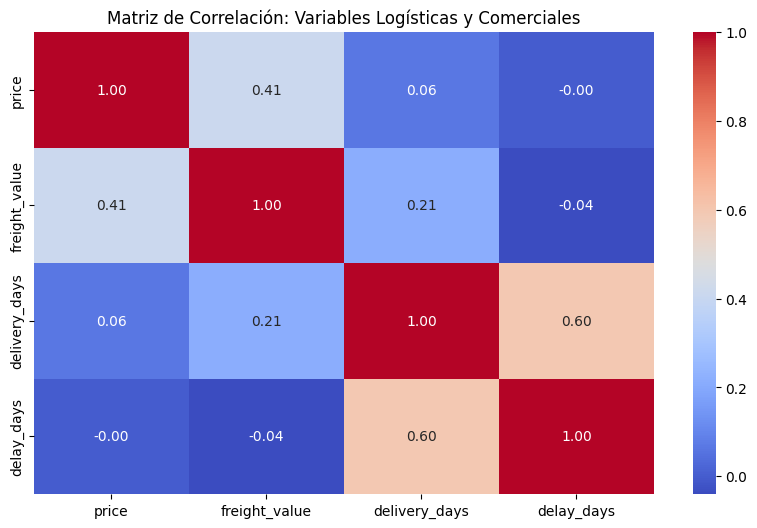

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar variables de interés
corr_matrix = df[['price', 'freight_value', 'delivery_days', 'delay_days']].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación: Variables Logísticas y Comerciales')
plt.show()

In [78]:
df[['price','freight_value','delivery_days','delay_days']].agg(['skew','kurtosis'])

,price,freight_value,delivery_days,delay_days
skew,7.923208,5.639870,3.834341,1.899364
kurtosis,120.828298,59.788253,39.779533,27.708333


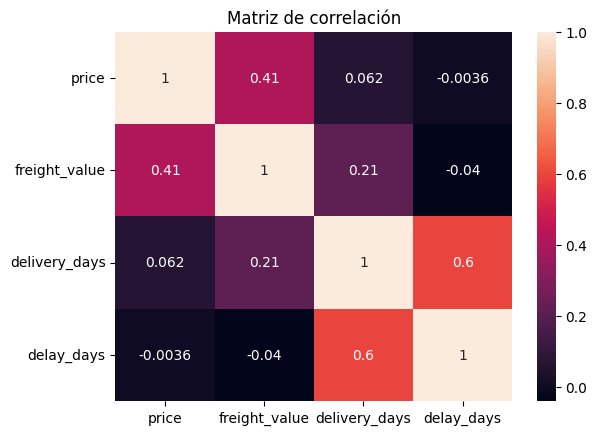

In [79]:
corr = df[['price','freight_value','delivery_days','delay_days']].corr()

sns.heatmap(corr, annot=True)
plt.title("Matriz de correlación")
plt.show()

In [80]:
# Ratio freight / price
df['freight_ratio'] = df['freight_value'] / df['price']

df['freight_ratio'].describe(percentiles=[0.5,0.75,0.9,0.95])

count    112650.000000
mean          0.320864
std           0.349894
min           0.000000
50%           0.231356
75%           0.393036
90%           0.642857
95%           0.874702
max          26.235294
Name: freight_ratio, dtype: float64

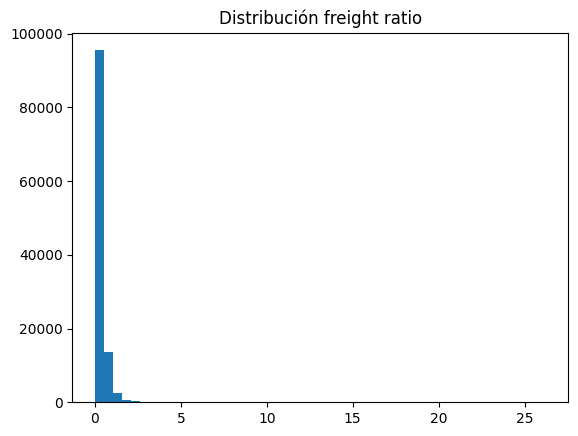

In [81]:
plt.hist(df['freight_ratio'], bins=50)
plt.title("Distribución freight ratio")
plt.show()

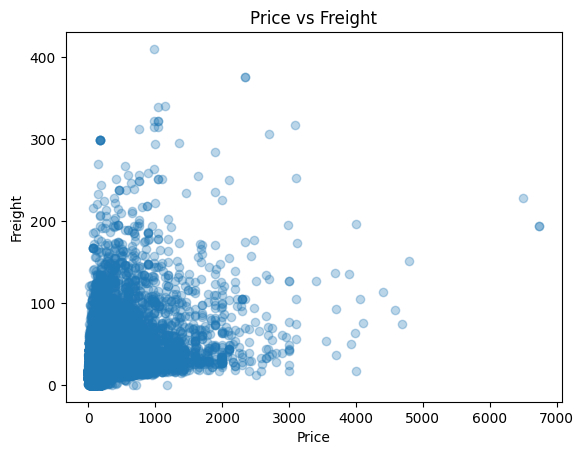

In [82]:
# Relación precio vs freight
plt.scatter(df['price'], df['freight_value'], alpha=0.3)
plt.xlabel("Price")
plt.ylabel("Freight")
plt.title("Price vs Freight")
plt.show()

In [83]:
df['freight_value'].describe()

count    112650.000000
mean         19.990320
std          15.806405
min           0.000000
25%          13.080000
50%          16.260000
75%          21.150000
max         409.680000
Name: freight_value, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

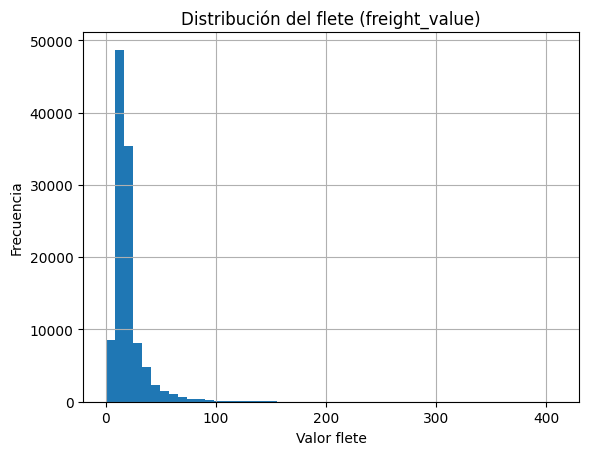

In [84]:
plt.Figure(figsize=(12,6))
df['freight_value'].hist(bins=50)
plt.title('Distribución del flete (freight_value)')
plt.xlabel('Valor flete')
plt.ylabel('Frecuencia')
plt.show

In [ ]:
# Resumen 

print(f"ESTRUCTURA DEL DATASET")
print(f"Total de Filas: {df.shape[0]}")
print(f"Total de Columnas: {df.shape[1]}")
print("-" * 30)

# 2. Tabla de auditoría detallada
resumen_calidad = pd.DataFrame({
    'Tipo de Dato': df.dtypes,
    'Registros No Nulos': df.count(),
    'Valores Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().sum() / len(df) * 100).round(2),
    'Valores Únicos': df.nunique()
})

# 3. Tabla e integridad de filas
display(resumen_calidad)
print("-" * 30)
print(f"Duplicados totales en el dataset: {df.duplicated().sum()}")

ESTRUCTURA DEL DATASET
Total de Filas: 112650
Total de Columnas: 28
------------------------------


,Tipo de Dato,Registros No Nulos,Valores Nulos,% Nulos,Valores Únicos
order_id,object,112650,0,0.00,98666
order_item_id,int64,112650,0,0.00,21
product_id,object,112650,0,0.00,32951
seller_id,object,112650,0,0.00,3095
customer_id,object,112650,0,0.00,98666
customer_unique_id,object,112650,0,0.00,95420
price,float64,112650,0,0.00,5968
freight_value,float64,112650,0,0.00,6999
order_status,object,112650,0,0.00,7
order_purchase_timestamp,datetime64[ns],112650,0,0.00,98112


------------------------------
Duplicados totales en el dataset: 0


In [86]:
# Asegúrate de que el diccionario state_map esté definido antes
df_delivered['customer_state_full'] = df_delivered['customer_state'].map(state_map)

In [ ]:
# Tiempo promedio de entrega por estado del cliente

delivery_by_state = (
    df_delivered.groupby('customer_state_full')['delivery_days']
    .agg(['count', 'mean', 'median'])
    .sort_values(by='mean', ascending=False)
)

delivery_by_state.head(10)

,count,mean,median
customer_state_full,,,
Roraima,46,27.826087,24.5
Aapá,81,27.753086,24.0
Amazonas,163,25.963190,26.0
Alagoas,427,23.992974,22.0
Pará,1054,23.301708,21.0
Maranhão,800,21.203750,19.0
Sergipe,375,20.978667,17.0
Ceará,1426,20.537167,18.0
Acre,91,20.329670,18.0


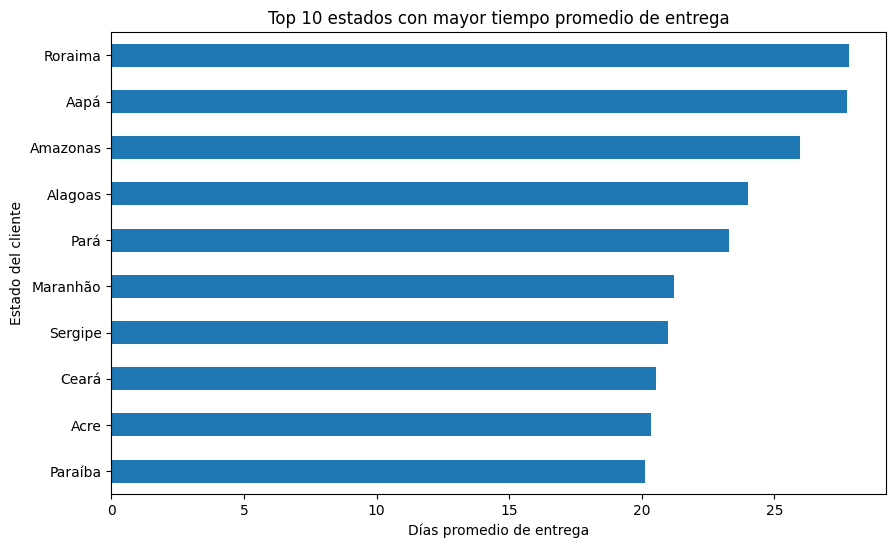

In [ ]:
# Estados con mayor tiempo de entrega

plt.figure(figsize=(10,6))
delivery_by_state.head(10)['mean'].sort_values().plot(kind='barh')
plt.title('Top 10 estados con mayor tiempo promedio de entrega')
plt.xlabel('Días promedio de entrega')
plt.ylabel('Estado del cliente')
plt.show()

In [ ]:
# Retraso promedio por estado del cliente

delay_by_state = (
    df_delivered.groupby('customer_state_full')['delay_days']
    .agg(['count', 'mean', 'median'])
    .sort_values(by='mean', ascending=False)
)

delay_by_state.head(10)


,count,mean,median
customer_state_full,,,
Alagoas,427,-8.735363,-10.0
Maranhão,800,-9.906250,-11.0
Sergipe,375,-10.002667,-13.0
Espírito Santo,2225,-10.646292,-12.0
Bahia,3683,-10.982623,-12.0
Ceará,1426,-11.103787,-13.0
São Paulo,46441,-11.206456,-11.0
Mato Grosso do Sul,811,-11.229346,-13.0
Piauí,523,-11.527725,-14.0


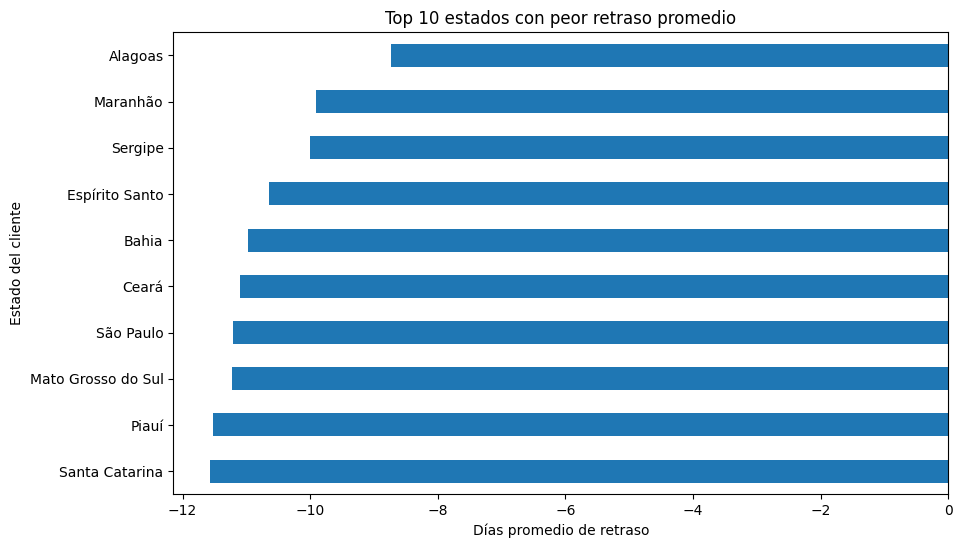

In [ ]:
# Visualizar estados con peor retraso promedio

plt.figure(figsize=(10,6))
delay_by_state.head(10)['mean'].sort_values().plot(kind='barh')
plt.title('Top 10 estados con peor retraso promedio')
plt.xlabel('Días promedio de retraso')
plt.ylabel('Estado del cliente')
plt.show()

In [ ]:
# Porcentaje de pedidos retrasados por estado

late_pct_by_state = (
    df_delivered.groupby('customer_state_full')['delay_days']
    .apply(lambda x: (x > 0).mean() * 100)
    .sort_values(ascending=False)
)

late_pct_by_state.head(10)

customer_state_full
Alagoas           20.843091
Maranhão          18.000000
Sergipe           16.266667
Ceará             13.604488
Piauí             13.575526
Bahia             11.892479
Rio de Janeiro    11.624125
Pará              11.290323
Roraima           10.869565
Paraíba           10.750853
Name: delay_days, dtype: float64

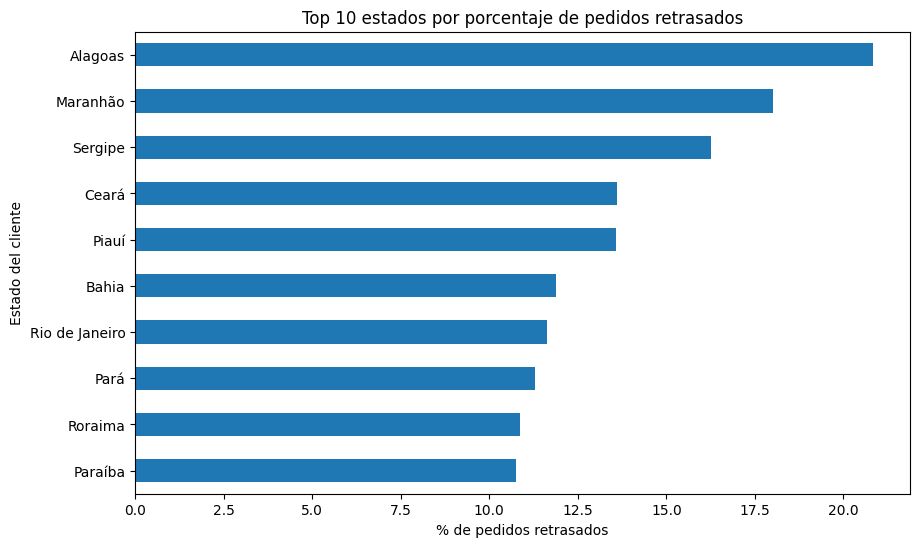

In [ ]:
# Visualizar porcentaje de pedidos retrasados por estado

plt.figure(figsize=(10,6))
late_pct_by_state.head(10).sort_values().plot(kind='barh')
plt.title('Top 10 estados por porcentaje de pedidos retrasados')
plt.xlabel('% de pedidos retrasados')
plt.ylabel('Estado del cliente')
plt.show()

In [ ]:
# Construir tabla logística geográfica consolidada

geo_log_summary = pd.DataFrame({
    'delivered_orders': df_delivered.groupby('customer_state_full')['order_id'].nunique(),
    'avg_delivery_days': df_delivered.groupby('customer_state_full')['delivery_days'].mean(),
    'median_delivery_days': df_delivered.groupby('customer_state_full')['delivery_days'].median(),
    'avg_delay_days': df_delivered.groupby('customer_state_full')['delay_days'].mean(),
    'late_orders_pct': df_delivered.groupby('customer_state_full')['delay_days'].apply(lambda x: (x > 0).mean() * 100)
}).sort_values(by='avg_delivery_days', ascending=False)

geo_log_summary.head(15)

,delivered_orders,avg_delivery_days,median_delivery_days,avg_delay_days,late_orders_pct
customer_state_full,,,,,
Roraima,41,27.826087,24.5,-18.326087,10.869565
Aapá,67,27.753086,24.0,-18.395062,3.703704
Amazonas,145,25.963190,26.0,-19.932515,3.067485
Alagoas,397,23.992974,22.0,-8.735363,20.843091
Pará,946,23.301708,21.0,-14.250474,11.290323
Maranhão,717,21.203750,19.0,-9.906250,18.000000
Sergipe,335,20.978667,17.0,-10.002667,16.266667
Ceará,1279,20.537167,18.0,-11.103787,13.604488
Acre,80,20.329670,18.0,-20.978022,3.296703


In [ ]:
# Filtrar estados con suficiente volumen

geo_log_summary_filtered = geo_log_summary[
    geo_log_summary['delivered_orders'] >= 100
].copy()

geo_log_summary_filtered.head(15)

,delivered_orders,avg_delivery_days,median_delivery_days,avg_delay_days,late_orders_pct
customer_state_full,,,,,
Amazonas,145,25.963190,26.0,-19.932515,3.067485
Alagoas,397,23.992974,22.0,-8.735363,20.843091
Pará,946,23.301708,21.0,-14.250474,11.290323
Maranhão,717,21.203750,19.0,-9.906250,18.000000
Sergipe,335,20.978667,17.0,-10.002667,16.266667
Ceará,1279,20.537167,18.0,-11.103787,13.604488
Paraíba,517,20.119454,18.0,-13.037543,10.750853
Rondônia,243,19.282051,18.0,-20.040293,4.029304
Piauí,476,18.931166,16.0,-11.527725,13.575526


In [95]:
df_log_reviews['customer_state_full'] = df_log_reviews['customer_state'].map(state_map)

In [ ]:
# Geografía + satisfacción

state_review_summary = (
    df_log_reviews.groupby('customer_state_full')['avg_review_score']
    .agg(['count', 'mean', 'median'])
    .sort_values(by='mean', ascending=True)
)

state_review_summary.head(15)

,count,mean,median
customer_state_full,,,
Maranhão,794,3.759446,4.0
Alagoas,424,3.825472,4.0
Pará,1034,3.838491,4.0
Bahia,3649,3.861332,4.0
Ceará,1419,3.872445,5.0
Rio de Janeiro,13970,3.874219,5.0
Roraima,46,3.891304,4.5
Sergipe,373,3.898123,5.0
Piauí,518,3.959459,5.0


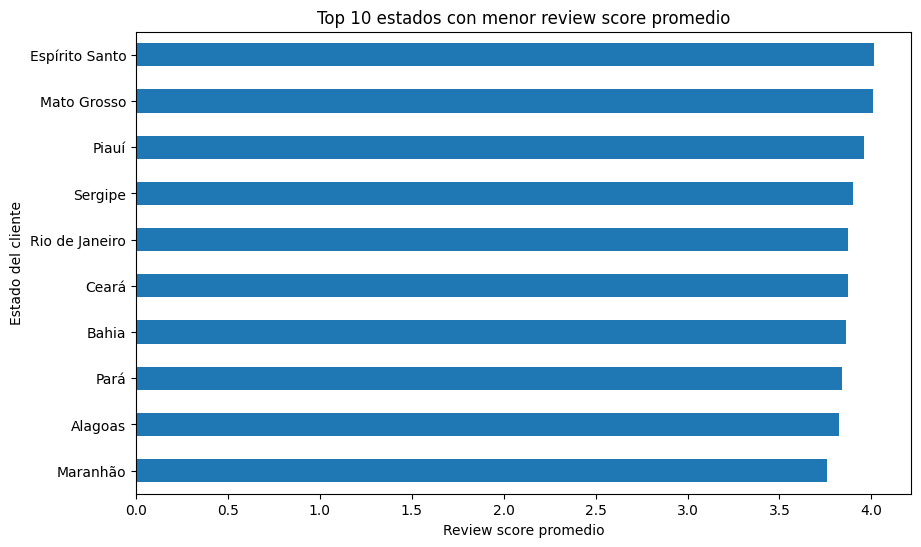

In [97]:
plt.figure(figsize=(10,6))
state_review_summary[state_review_summary['count'] >= 100].head(10)['mean'].sort_values().plot(kind='barh')
plt.title('Top 10 estados con menor review score promedio')
plt.xlabel('Review score promedio')
plt.ylabel('Estado del cliente')
plt.show()

In [98]:
# Cruce con logística

state_log_review_compare = geo_log_summary_filtered.merge(
    state_review_summary[['mean']].rename(columns={'mean': 'avg_review_score'}),
    left_index=True,
    right_index=True,
    how='left'
)

state_log_review_compare.sort_values(by='avg_review_score').head(15)

,delivered_orders,avg_delivery_days,median_delivery_days,avg_delay_days,late_orders_pct,avg_review_score
customer_state_full,,,,,,
Maranhão,717,21.203750,19.0,-9.906250,18.000000,3.759446
Alagoas,397,23.992974,22.0,-8.735363,20.843091,3.825472
Pará,946,23.301708,21.0,-14.250474,11.290323,3.838491
Bahia,3256,18.774640,16.0,-10.982623,11.892479,3.861332
Ceará,1279,20.537167,18.0,-11.103787,13.604488,3.872445
Rio de Janeiro,12350,14.688821,11.0,-12.009899,11.624125,3.874219
Sergipe,335,20.978667,17.0,-10.002667,16.266667,3.898123
Piauí,476,18.931166,16.0,-11.527725,13.575526,3.959459
Mato Grosso,886,17.508197,16.0,-14.571842,6.075217,4.007310


In [100]:
df['is_late'] = df['delay_days'] > 0

In [101]:
df['year_month'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)

In [102]:
df['weekday'] = df['order_purchase_timestamp'].dt.day_name()

# 4. Construcción del dataset para Power BI

Se prepara una estructura de datos optimizada para su explotación en Power BI, incorporando las variables y métricas necesarias para el desarrollo del modelo dimensional y las visualizaciones de negocio.

In [103]:
# Crear dataset final

df_final = df[[
    'order_id',
    'customer_unique_id',
    'product_id',
    'seller_id',
    'order_purchase_timestamp',
    'year',
    'month',
    'weekday',
    'year_month',
    'price',
    'freight_value',
    'freight_ratio',
    'product_category_final',
    'customer_state',
    'seller_state',
    'delivery_days',
    'delay_days',
    'is_late'
]].copy()

In [104]:
# Exportar

df_final.to_csv('olist_final_dataset.csv', index=False)

In [105]:
df_final.head()

,order_id,customer_unique_id,product_id,seller_id,order_purchase_timestamp,year,month,weekday,year_month,price,freight_value,freight_ratio,product_category_final,customer_state,seller_state,delivery_days,delay_days,is_late
0,00010242fe8c5a6d1ba2dd792cb16214,871766c5855e863f6eccc05f988b23cb,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-13 08:59:02,2017,9,Wednesday,2017-09,58.90,13.29,0.225637,cool_stuff,RJ,SP,7.0,-9.0,False
1,00018f77f2f0320c557190d7a144bdd3,eb28e67c4c0b83846050ddfb8a35d051,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-04-26 10:53:06,2017,4,Wednesday,2017-04,239.90,19.93,0.083076,pet_shop,SP,SP,16.0,-3.0,False
2,000229ec398224ef6ca0657da4fc703e,3818d81c6709e39d06b2738a8d3a2474,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-14 14:33:31,2018,1,Sunday,2018-01,199.00,17.87,0.089799,furniture_decor,MG,MG,7.0,-14.0,False
3,00024acbcdf0a6daa1e931b038114c75,af861d436cfc08b2c2ddefd0ba074622,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-08 10:00:35,2018,8,Wednesday,2018-08,12.99,12.79,0.984604,perfumery,SP,SP,6.0,-6.0,False
4,00042b26cf59d7ce69dfabb4e55b4fd9,64b576fb70d441e8f1b2d7d446e483c5,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-04 13:57:51,2017,2,Saturday,2017-02,199.90,18.14,0.090745,garden_tools,SP,PR,25.0,-16.0,False


In [106]:
df_final.shape

(112650, 18)

In [107]:
df_final.columns

Index(['order_id', 'customer_unique_id', 'product_id', 'seller_id',
       'order_purchase_timestamp', 'year', 'month', 'weekday', 'year_month',
       'price', 'freight_value', 'freight_ratio', 'product_category_final',
       'customer_state', 'seller_state', 'delivery_days', 'delay_days',
       'is_late'],
      dtype='object')

In [108]:
df_powerbi = df[[
    'order_id',
    'product_id',
    'seller_id',
    'customer_unique_id',

    'order_purchase_timestamp',
    'year',
    'month',
    'year_month',
    'weekday',

    'order_status',

    'price',
    'freight_value',
    'freight_ratio',

    'product_category_final',

    'customer_state_full',
    'seller_state_full',

    'delivery_days',
    'delay_days',
    'is_late'
]].copy()

In [109]:
df_powerbi.to_csv('olist_powerbi_dataset.csv', index=False)

In [111]:
df_powerbi

,order_id,product_id,seller_id,customer_unique_id,order_purchase_timestamp,year,month,year_month,weekday,order_status,price,freight_value,freight_ratio,product_category_final,customer_state_full,seller_state_full,delivery_days,delay_days,is_late
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,871766c5855e863f6eccc05f988b23cb,2017-09-13 08:59:02,2017,9,2017-09,Wednesday,delivered,58.90,13.29,0.225637,cool_stuff,Rio de Janeiro,São Paulo,7.0,-9.0,False
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,eb28e67c4c0b83846050ddfb8a35d051,2017-04-26 10:53:06,2017,4,2017-04,Wednesday,delivered,239.90,19.93,0.083076,pet_shop,São Paulo,São Paulo,16.0,-3.0,False
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,3818d81c6709e39d06b2738a8d3a2474,2018-01-14 14:33:31,2018,1,2018-01,Sunday,delivered,199.00,17.87,0.089799,furniture_decor,Minas Gerais,Minas Gerais,7.0,-14.0,False
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,af861d436cfc08b2c2ddefd0ba074622,2018-08-08 10:00:35,2018,8,2018-08,Wednesday,delivered,12.99,12.79,0.984604,perfumery,São Paulo,São Paulo,6.0,-6.0,False
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,64b576fb70d441e8f1b2d7d446e483c5,2017-02-04 13:57:51,2017,2,2017-02,Saturday,delivered,199.90,18.14,0.090745,garden_tools,São Paulo,Paraná,25.0,-16.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,0c9aeda10a71f369396d0c04dce13a64,2018-04-23 13:57:06,2018,4,2018-04,Monday,delivered,299.99,43.41,0.144705,housewares,Maranhão,Santa Catarina,17.0,-8.0,False
112646,fffcd46ef2263f404302a634eb57f7eb,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,0da9fe112eae0c74d3ba1fe16de0988b,2018-07-14 10:26:46,2018,7,2018-07,Saturday,delivered,350.00,36.53,0.104371,computers_accessories,Paraná,São Paulo,9.0,-9.0,False
112647,fffce4705a9662cd70adb13d4a31832d,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,cd79b407828f02fdbba457111c38e4c4,2017-10-23 17:07:56,2017,10,2017-10,Monday,delivered,99.90,16.95,0.169670,sports_leisure,São Paulo,Paraná,4.0,-13.0,False
112648,fffe18544ffabc95dfada21779c9644f,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,eb803377c9315b564bdedad672039306,2017-08-14 23:02:59,2017,8,2017-08,Monday,delivered,55.99,8.72,0.155742,computers_accessories,São Paulo,São Paulo,1.0,-9.0,False


In [112]:
df.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id', 'customer_id',
       'customer_unique_id', 'price', 'freight_value', 'order_status',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'product_category_name',
       'product_category_name_english', 'product_category_final',
       'customer_city', 'customer_state', 'seller_city', 'seller_state',
       'year', 'month', 'delivery_days', 'delay_days', 'customer_state_full',
       'seller_state_full', 'freight_ratio', 'is_late', 'year_month',
       'weekday'],
      dtype='object')

In [113]:
df_log_reviews

,order_id,order_item_id,product_id,seller_id,customer_id,customer_unique_id,price,freight_value,order_status,order_purchase_timestamp,...,seller_city,seller_state,year,month,delivery_days,delay_days,avg_review_score,is_late,delay_bucket,customer_state_full
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,58.90,13.29,delivered,2017-09-13 08:59:02,...,volta redonda,SP,2017,9,7.0,-9.0,5.0,False,antes,Rio de Janeiro
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,239.90,19.93,delivered,2017-04-26 10:53:06,...,sao paulo,SP,2017,4,16.0,-3.0,4.0,False,ligeramente antes,São Paulo
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,199.00,17.87,delivered,2018-01-14 14:33:31,...,borda da mata,MG,2018,1,7.0,-14.0,5.0,False,antes,Minas Gerais
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,12.99,12.79,delivered,2018-08-08 10:00:35,...,franca,SP,2018,8,6.0,-6.0,4.0,False,ligeramente antes,São Paulo
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,199.90,18.14,delivered,2017-02-04 13:57:51,...,loanda,PR,2017,2,25.0,-16.0,5.0,False,mucho antes,São Paulo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110184,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,b51593916b4b8e0d6f66f2ae24f2673d,0c9aeda10a71f369396d0c04dce13a64,299.99,43.41,delivered,2018-04-23 13:57:06,...,itajai,SC,2018,4,17.0,-8.0,5.0,False,antes,Maranhão
110185,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,84c5d4fbaf120aae381fad077416eaa0,0da9fe112eae0c74d3ba1fe16de0988b,350.00,36.53,delivered,2018-07-14 10:26:46,...,sao paulo,SP,2018,7,9.0,-9.0,5.0,False,antes,Paraná
110186,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,29309aa813182aaddc9b259e31b870e6,cd79b407828f02fdbba457111c38e4c4,99.90,16.95,delivered,2017-10-23 17:07:56,...,curitiba,PR,2017,10,4.0,-13.0,5.0,False,antes,São Paulo
110187,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,b5e6afd5a41800fdf401e0272ca74655,eb803377c9315b564bdedad672039306,55.99,8.72,delivered,2017-08-14 23:02:59,...,sao paulo,SP,2017,8,1.0,-9.0,5.0,False,antes,São Paulo


In [114]:
df.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id', 'customer_id',
       'customer_unique_id', 'price', 'freight_value', 'order_status',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'product_category_name',
       'product_category_name_english', 'product_category_final',
       'customer_city', 'customer_state', 'seller_city', 'seller_state',
       'year', 'month', 'delivery_days', 'delay_days', 'customer_state_full',
       'seller_state_full', 'freight_ratio', 'is_late', 'year_month',
       'weekday'],
      dtype='object')

In [115]:
df['order_status'].unique()

array(['delivered', 'shipped', 'canceled', 'invoiced', 'processing',
       'approved', 'unavailable'], dtype=object)

# 5. Preparación de datos para modelos analíticos

En esta sección se seleccionan y transforman las variables necesarias para la aplicación de técnicas de aprendizaje automático, garantizando la calidad y comparabilidad de los datos.

In [116]:
df_drv = df_powerbi.copy()

# Seguridad básica
df_drv = df_drv[df_drv['price'].notna()].copy()
df_drv = df_drv[df_drv['freight_value'].notna()].copy()

In [ ]:
# Tamaño del pedido

order_size = (
    df_drv.groupby('order_id')
    .size()
    .reset_index(name='order_size_items')
)

df_drv = df_drv.merge(order_size, on='order_id', how='left')

In [ ]:
import pandas as pd
import numpy as np

# freight_ratio

df_drv['freight_ratio'] = np.where(
    df_drv['price'] > 0,
    df_drv['freight_value'] / df_drv['price'],
    np.nan
)

In [ ]:
# Target reputacional

# 1. Unir dataset de items con el de reviews
df_drv1 = df_drv.merge(reviews_order, on='order_id', how='left')

# 2. Cear la variable 'bad_review'
# Usar columna 'avg_review_score' 
df_drv1['bad_review'] = (df_drv1['avg_review_score'] <= 2).astype(int)

In [ ]:
# Bins útiles para análisis

df_drv1['freight_ratio_bin'] = pd.qcut(
    df_drv1['freight_ratio'],
    q=5,
    duplicates='drop'
)

df_drv1['delivery_days_bin'] = pd.qcut(
    df_drv1['delivery_days'],
    q=5,
    duplicates='drop'
)

In [ ]:
# Variables adicionales 

# same_state = cliente y vendedor en el mismo estado
# high_ticket = percentil alto de price
# high_freight_ratio = percentil alto de freight_ratio

df_drv1['same_state'] = (df_drv1['customer_state_full'] == df_drv1['seller_state_full']).astype(int)

p90_price = df_drv1['price'].quantile(0.90)
df_drv1['high_ticket'] = (df_drv1['price'] >= p90_price).astype(int)

p90_fr = df_drv1['freight_ratio'].quantile(0.90)
df_drv1['high_freight_ratio'] = (df_drv1['freight_ratio'] >= p90_fr).astype(int)

In [124]:
sns.set_theme(style="whitegrid")

In [ ]:
# Análisis exploratorio de drivers para is_late

# 1 Tasa de retraso global
late_rate = df_drv1['is_late'].mean()
print(f"Tasa global de retraso: {late_rate:.2%}")

Tasa global de retraso: 6.45%


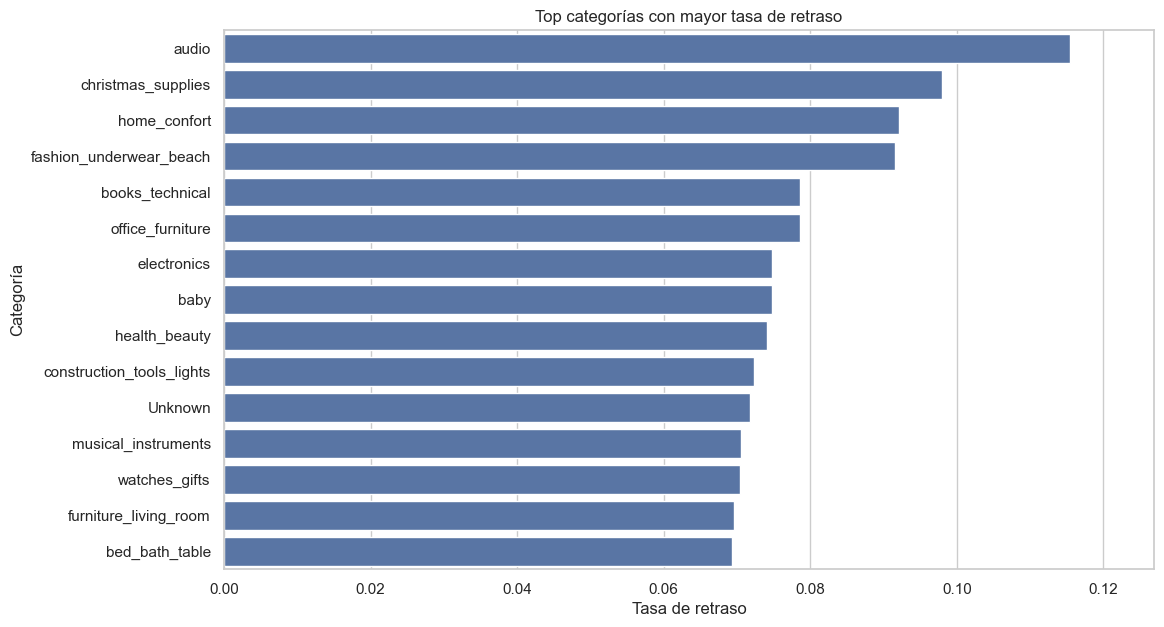

In [ ]:
# Tasa de retraso por categoría

late_by_cat = (
    df_drv1.groupby('product_category_final')
    .agg(
        late_rate=('is_late', 'mean'),
        orders=('order_id', 'nunique'),
        items=('order_id', 'size')
    )
    .reset_index()
)

late_by_cat = late_by_cat[late_by_cat['orders'] >= 100]  # filtro mínimo para estabilidad
late_by_cat = late_by_cat.sort_values('late_rate', ascending=False).head(15)

plt.figure(figsize=(12, 7))
sns.barplot(data=late_by_cat, x='late_rate', y='product_category_final')
plt.title('Top categorías con mayor tasa de retraso')
plt.xlabel('Tasa de retraso')
plt.ylabel('Categoría')
plt.xlim(0, late_by_cat['late_rate'].max() * 1.1)
plt.show()

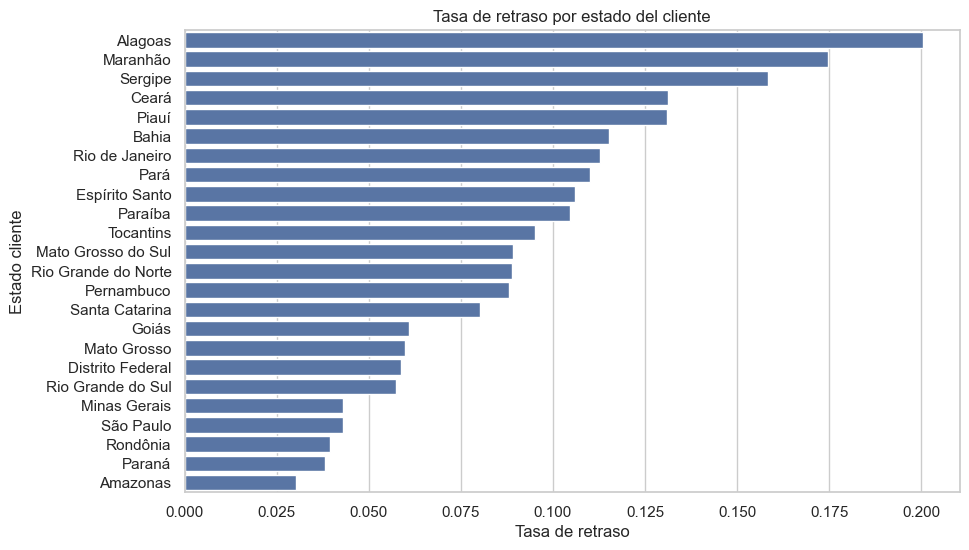

In [ ]:
# Tasa de retraso por estado del cliente

late_by_cstate = (
    df_drv1.groupby('customer_state_full')
    .agg(
        late_rate=('is_late', 'mean'),
        orders=('order_id', 'nunique')
    )
    .reset_index()
    .query("orders >= 100")
    .sort_values('late_rate', ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=late_by_cstate, x='late_rate', y='customer_state_full')
plt.title('Tasa de retraso por estado del cliente')
plt.xlabel('Tasa de retraso')
plt.ylabel('Estado cliente')
plt.show()

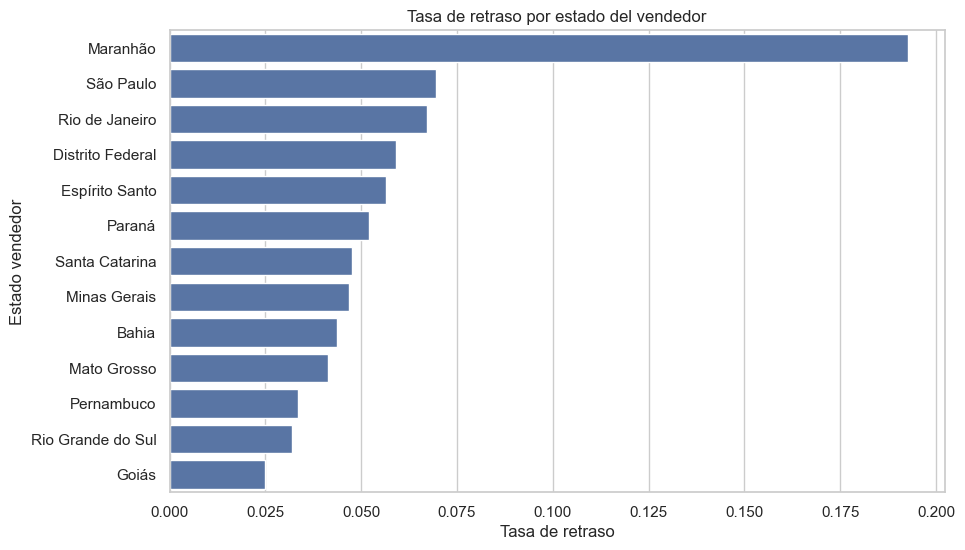

In [ ]:
# Tasa de retraso por estado del vendedor

late_by_sstate = (
    df_drv1.groupby('seller_state_full')
    .agg(
        late_rate=('is_late', 'mean'),
        orders=('order_id', 'nunique')
    )
    .reset_index()
    .query("orders >= 100")
    .sort_values('late_rate', ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=late_by_sstate, x='late_rate', y='seller_state_full')
plt.title('Tasa de retraso por estado del vendedor')
plt.xlabel('Tasa de retraso')
plt.ylabel('Estado vendedor')
plt.show()

In [133]:
late_same_state = (
    df_drv1.groupby('same_state')['is_late']
    .mean()
    .reset_index()
)

print(late_same_state)

   same_state   is_late
0           0  0.076390
1           1  0.043503


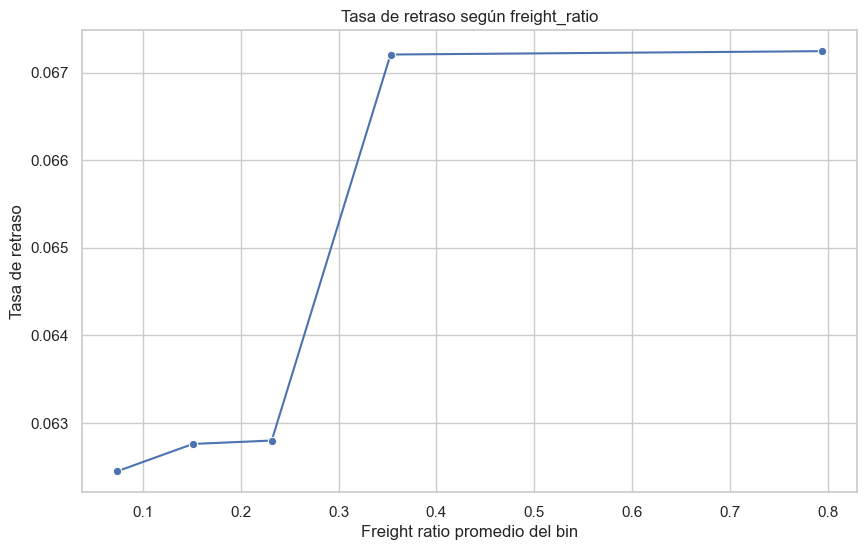

In [ ]:
# Relación entre freight_ratio e is_late

late_by_fr = (
    df_drv1.groupby('freight_ratio_bin', observed=False)
    .agg(
        late_rate=('is_late', 'mean'),
        avg_fr=('freight_ratio', 'mean'),
        orders=('order_id', 'nunique')
    )
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.lineplot(data=late_by_fr, x='avg_fr', y='late_rate', marker='o')
plt.title('Tasa de retraso según freight_ratio')
plt.xlabel('Freight ratio promedio del bin')
plt.ylabel('Tasa de retraso')
plt.show()

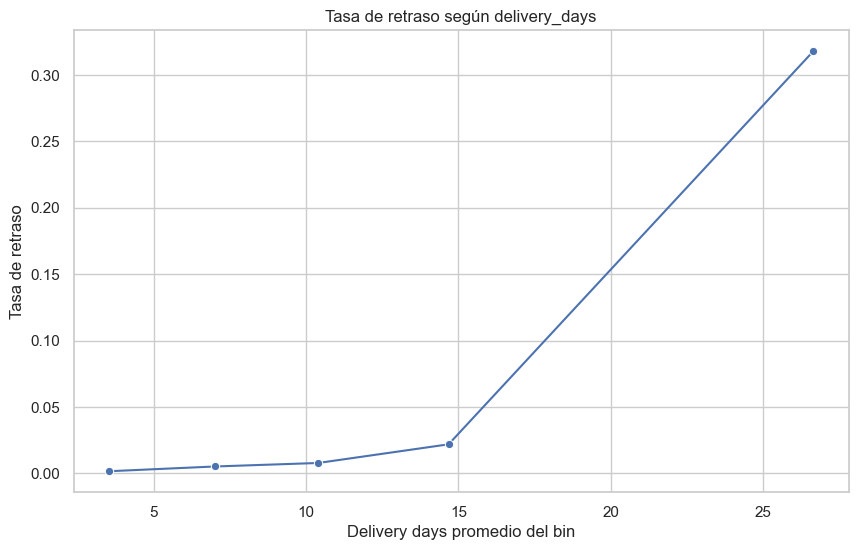

In [ ]:
# Relación entre delivery_days e is_late

late_by_dd = (
    df_drv1.groupby('delivery_days_bin', observed=False)
    .agg(
        late_rate=('is_late', 'mean'),
        avg_delivery=('delivery_days', 'mean')
    )
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.lineplot(data=late_by_dd, x='avg_delivery', y='late_rate', marker='o')
plt.title('Tasa de retraso según delivery_days')
plt.xlabel('Delivery days promedio del bin')
plt.ylabel('Tasa de retraso')
plt.show()

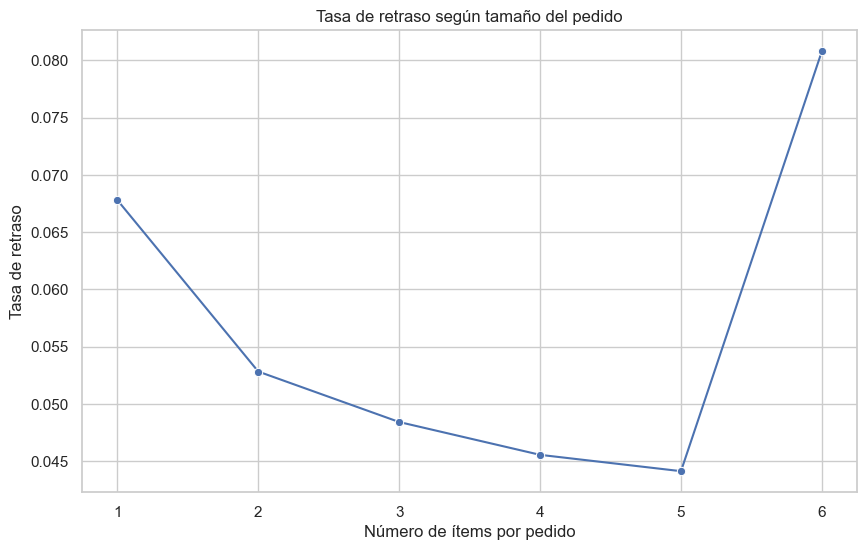

In [ ]:
# Relación con tamaño del pedido

late_by_size = (
    df_drv.groupby('order_size_items')
    .agg(
        late_rate=('is_late', 'mean'),
        orders=('order_id', 'nunique')
    )
    .reset_index()
)

late_by_size = late_by_size[late_by_size['orders'] >= 50]

plt.figure(figsize=(10, 6))
sns.lineplot(data=late_by_size, x='order_size_items', y='late_rate', marker='o')
plt.title('Tasa de retraso según tamaño del pedido')
plt.xlabel('Número de ítems por pedido')
plt.ylabel('Tasa de retraso')
plt.show()

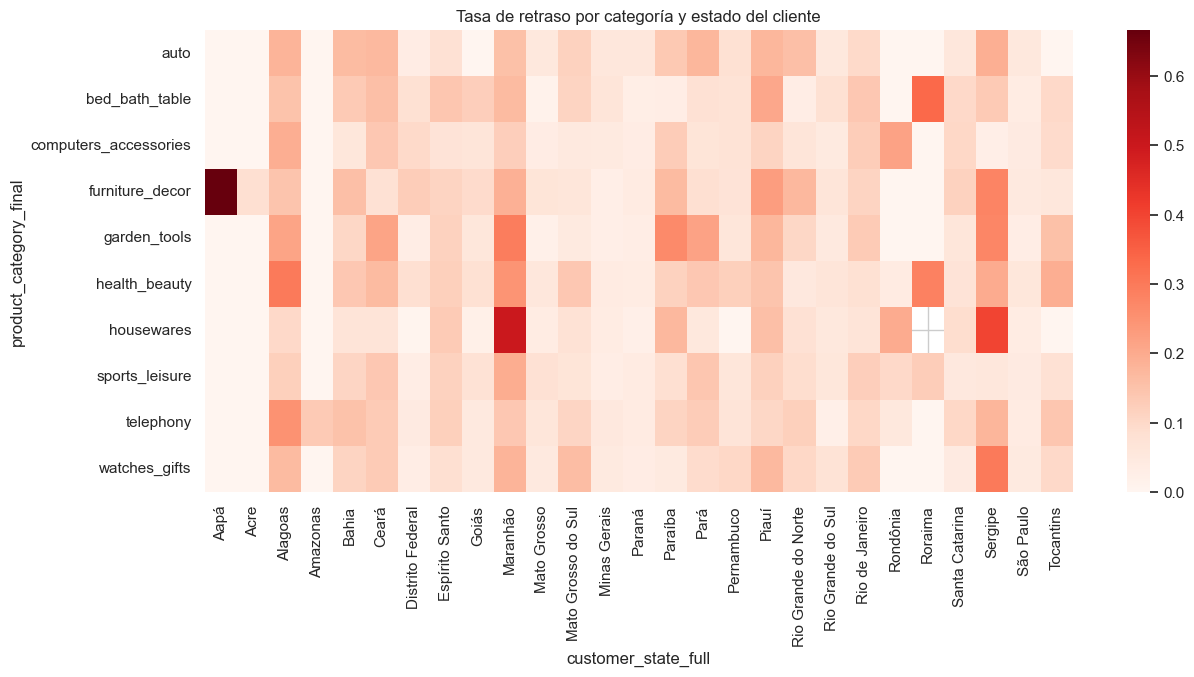

In [ ]:
# Heatmap categoría × estado

top_cats = (
    df_drv1['product_category_final']
    .value_counts()
    .head(10)
    .index
)

heat = (
    df_drv1[df_drv1['product_category_final'].isin(top_cats)]
    .pivot_table(
        index='product_category_final',
        columns='customer_state_full',
        values='is_late',
        aggfunc='mean'
    )
)

plt.figure(figsize=(14, 6))
sns.heatmap(heat, cmap='Reds', annot=False)
plt.title('Tasa de retraso por categoría y estado del cliente')
plt.show()

In [139]:
reviews_aux = (
    reviews_order[['order_id', 'avg_review_score']]
    .dropna()
    .copy()
)

In [140]:
reviews_aux = (
    reviews_aux.groupby('order_id', as_index=False)
    .agg(review_score=('avg_review_score', 'mean'))
)

In [141]:
df_rev = df_drv1.merge(reviews_aux, on='order_id', how='left')
df_rev = df_rev[df_rev['review_score'].notna()].copy()

df_rev['bad_review'] = (df_rev['review_score'] <= 2).astype(int)

In [142]:
review_by_late = (
    df_rev.groupby('is_late')
    .agg(
        avg_review=('review_score', 'mean'),
        bad_review_rate=('bad_review', 'mean'),
        orders=('order_id', 'nunique')
    )
    .reset_index()
)

print(review_by_late)

   is_late  avg_review  bad_review_rate  orders
0    False    4.153360         0.128804   91535
1     True    2.257411         0.628741    6382


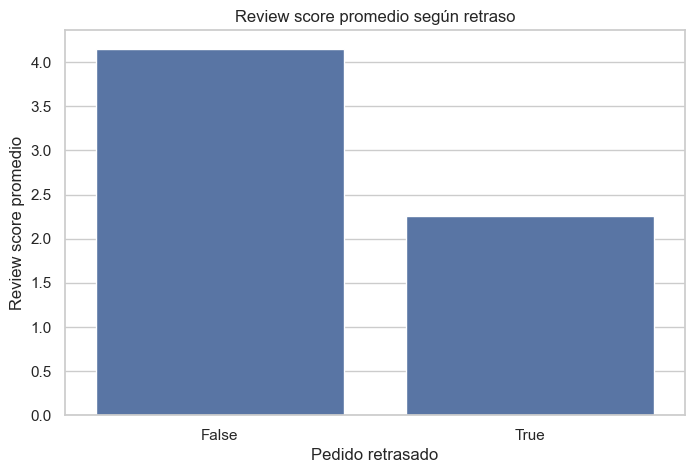

In [143]:
plt.figure(figsize=(8, 5))
sns.barplot(data=review_by_late, x='is_late', y='avg_review')
plt.title('Review score promedio según retraso')
plt.xlabel('Pedido retrasado')
plt.ylabel('Review score promedio')
plt.show()

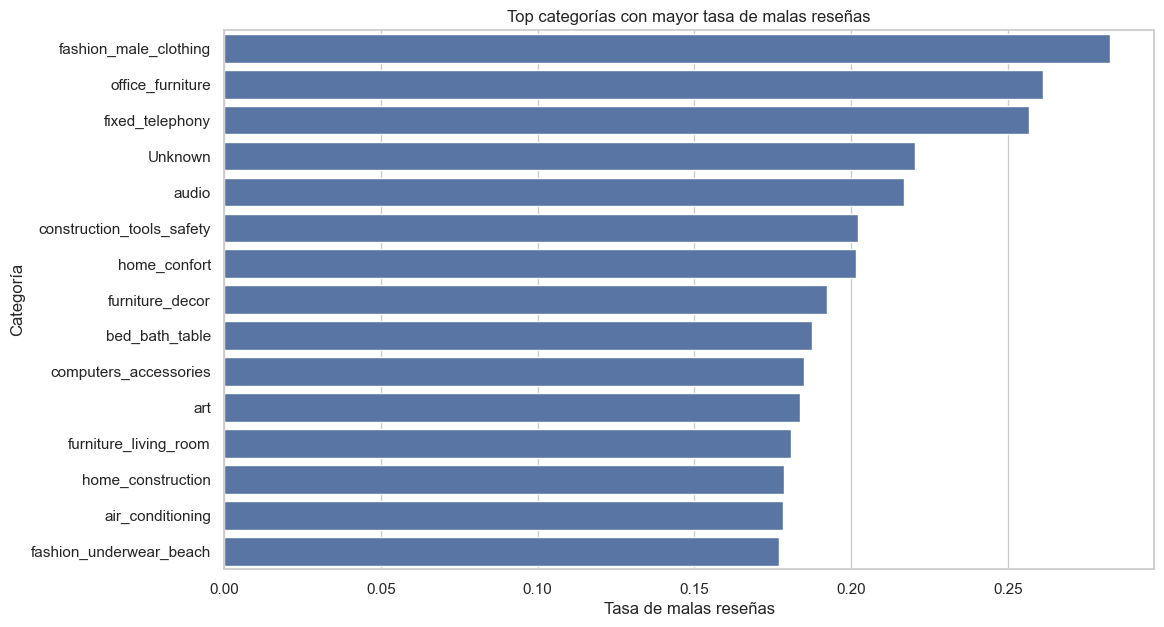

In [144]:
bad_by_cat = (
    df_rev.groupby('product_category_final')
    .agg(
        bad_review_rate=('bad_review', 'mean'),
        orders=('order_id', 'nunique')
    )
    .reset_index()
    .query("orders >= 100")
    .sort_values('bad_review_rate', ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 7))
sns.barplot(data=bad_by_cat, x='bad_review_rate', y='product_category_final')
plt.title('Top categorías con mayor tasa de malas reseñas')
plt.xlabel('Tasa de malas reseñas')
plt.ylabel('Categoría')
plt.show()

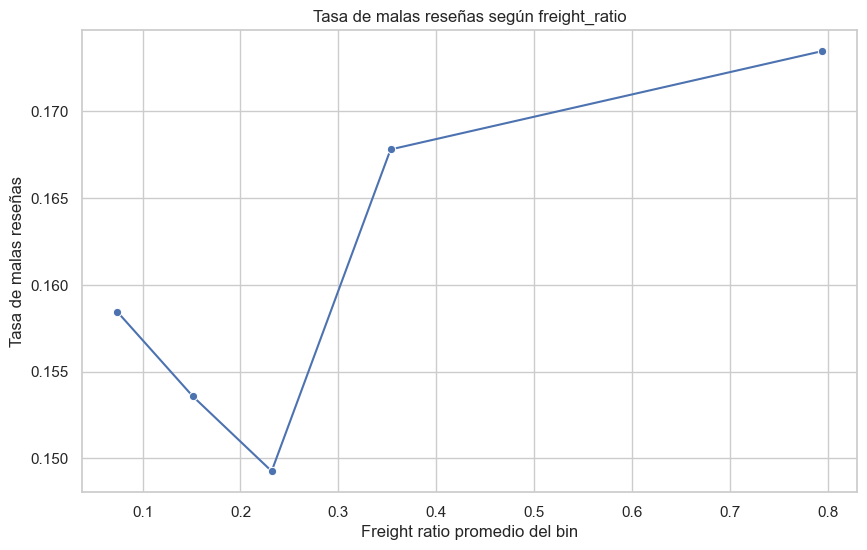

In [145]:
bad_by_fr = (
    df_rev.groupby('freight_ratio_bin', observed=False)
    .agg(
        bad_review_rate=('bad_review', 'mean'),
        avg_fr=('freight_ratio', 'mean')
    )
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.lineplot(data=bad_by_fr, x='avg_fr', y='bad_review_rate', marker='o')
plt.title('Tasa de malas reseñas según freight_ratio')
plt.xlabel('Freight ratio promedio del bin')
plt.ylabel('Tasa de malas reseñas')
plt.show()

C:\Users\galoa\AppData\Local\Temp\ipykernel_11928\3562164814.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_rev.groupby(pd.qcut(df_rev['delay_days'], q=5, duplicates='drop'))


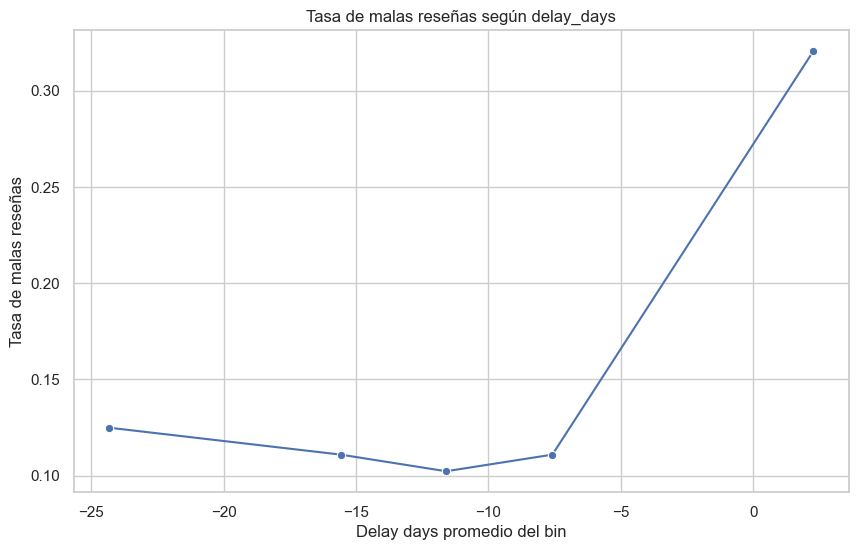

In [146]:
delay_review = (
    df_rev.groupby(pd.qcut(df_rev['delay_days'], q=5, duplicates='drop'))
    .agg(
        avg_delay=('delay_days', 'mean'),
        bad_review_rate=('bad_review', 'mean')
    )
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.lineplot(data=delay_review, x='avg_delay', y='bad_review_rate', marker='o')
plt.title('Tasa de malas reseñas según delay_days')
plt.xlabel('Delay days promedio del bin')
plt.ylabel('Tasa de malas reseñas')
plt.show()

# Identificación de drivers clave

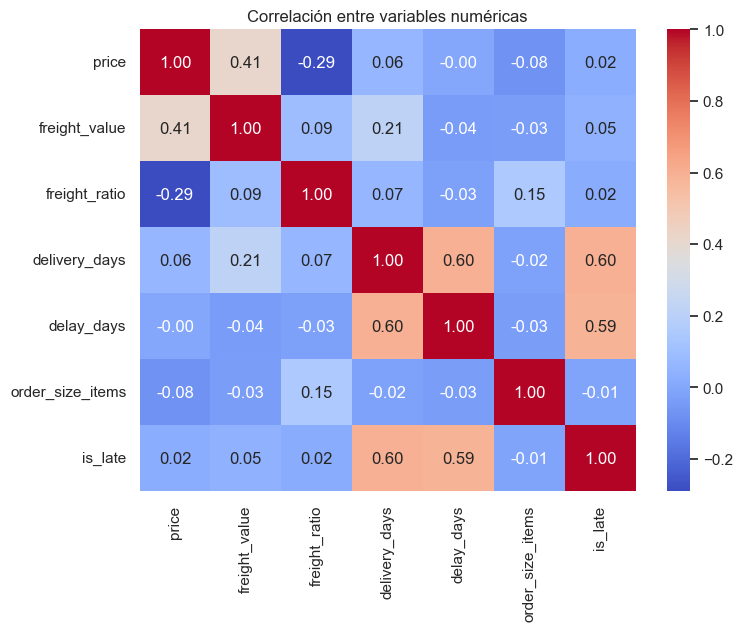

In [147]:
num_cols = ['price', 'freight_value', 'freight_ratio', 'delivery_days', 'delay_days', 'order_size_items', 'is_late']
corr = df_drv[num_cols].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlación entre variables numéricas')
plt.show()

In [148]:
global_late = df_drv['is_late'].mean()

summary_cat = (
    df_drv.groupby('product_category_final')
    .agg(
        late_rate=('is_late', 'mean'),
        orders=('order_id', 'nunique')
    )
    .reset_index()
)

summary_cat['pp_vs_global'] = (summary_cat['late_rate'] - global_late) * 100
summary_cat = summary_cat.sort_values('pp_vs_global', ascending=False)
print(summary_cat.head(10))

               product_category_final  late_rate  orders  pp_vs_global
47                     home_comfort_2   0.133333      24      6.884154
42  furniture_mattress_and_upholstery   0.131579      38      6.708716
5                               audio   0.115385     350      5.089283
13                 christmas_supplies   0.098039     128      3.354743
48                       home_confort   0.092166     397      2.767411
34            fashion_underwear_beach   0.091603     121      2.711126
58                   office_furniture   0.078652    1273      1.415990
11                    books_technical   0.078652     260      1.415990
27                        electronics   0.074810    2550      1.031848
7                                baby   0.074715    2885      1.022273


# 6. Preparación de datos para modelos analíticos

En esta sección se seleccionan y transforman las variables necesarias para la aplicación de técnicas de aprendizaje automático, garantizando la calidad y comparabilidad de los datos.

In [150]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

model_df = df_drv1[[
    'is_late',
    'price',
    'freight_value',
    'freight_ratio',
    'order_size_items',
    'product_category_final',
    'customer_state_full',
    'seller_state_full',
    'month',
    'weekday',
    'same_state'
]].dropna().copy()

X = model_df.drop(columns='is_late')
y = model_df['is_late']

num_features = ['price', 'freight_value', 'freight_ratio', 'order_size_items', 'month', 'same_state']
cat_features = ['product_category_final', 'customer_state_full', 'seller_state_full', 'weekday']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_features),
    ('cat', categorical_transformer, cat_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [151]:
log_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)
pred_log = log_model.predict(X_test)
proba_log = log_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred_log))
print("ROC AUC:", roc_auc_score(y_test, proba_log))

              precision    recall  f1-score   support

       False       0.94      1.00      0.97     21077
        True       0.00      0.00      0.00      1453

    accuracy                           0.94     22530
   macro avg       0.47      0.50      0.48     22530
weighted avg       0.88      0.94      0.90     22530

ROC AUC: 0.6442870586174686


c:\Gvlxo\Máster BI-BD\Computación Big Data\Practica 7.1\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Gvlxo\Máster BI-BD\Computación Big Data\Practica 7.1\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Gvlxo\Máste

In [153]:
payments_aux = (
    pd.read_sql_query("""
        SELECT 
            order_id,
            SUM(payment_value) AS payment_value_total,
            MAX(payment_installments) AS payment_installments_max,
            /* Tomamos el tipo de pago principal (el más común para ese pedido) */
            MAX(payment_type) AS payment_type_principal 
        FROM olist_order_payments_dataset
        GROUP BY order_id
    """, conn)
)

print(payments_aux.head())

                           order_id  payment_value_total  \
0  00010242fe8c5a6d1ba2dd792cb16214                72.19   
1  00018f77f2f0320c557190d7a144bdd3               259.83   
2  000229ec398224ef6ca0657da4fc703e               216.87   
3  00024acbcdf0a6daa1e931b038114c75                25.78   
4  00042b26cf59d7ce69dfabb4e55b4fd9               218.04   

   payment_installments_max payment_type_principal  
0                         2            credit_card  
1                         3            credit_card  
2                         5            credit_card  
3                         2            credit_card  
4                         3            credit_card  


# 6.1 Modelos explorados

# Análisis

In [157]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# 1. Preparar las variables (X) y el objetivo (y)
features = ['price', 'freight_value'] 
X = df_powerbi[features]
y = df_powerbi['is_late'].astype(int) # Convertir True/False a 1/0

# 2. Dividir datos (80% entrenamiento, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Entrenar el modelo
model = LogisticRegression()
model.fit(X_train, y_train)

# 4. Ver coeficientes
import numpy as np
coeff_df = pd.DataFrame({'Variable': features, 'Coeficiente': model.coef_[0]})
print(coeff_df)

        Variable  Coeficiente
0          price     0.000007
1  freight_value     0.008507


In [159]:
# Calcular el Revenue total que llegó tarde
revenue_at_risk = df_powerbi[df_powerbi['is_late'] == True]['price'].sum()
freight_at_risk = df_powerbi[df_powerbi['is_late'] == True]['freight_value'].sum()

print(f"Revenue en Riesgo: {revenue_at_risk:.2f}")
print(f"Costo Logístico en Riesgo: {freight_at_risk:.2f}")

Revenue en Riesgo: 985954.33
Costo Logístico en Riesgo: 164981.89


In [160]:
# Identificar pedidos ineficientes
inefficient_orders = df_powerbi[df_powerbi['freight_ratio'] > 0.40]
percentage_inefficient = (len(inefficient_orders) / len(df_powerbi)) * 100

print(f"Porcentaje de pedidos con logística ineficiente (>40%): {percentage_inefficient:.2f}%")

Porcentaje de pedidos con logística ineficiente (>40%): 24.24%


In [161]:
# Crear variable booleana: 1 si son estados distintos, 0 si es el mismo
df_powerbi['is_interstate'] = (df_powerbi['customer_state_full'] != df_powerbi['seller_state_full']).astype(int)

# Ver cuántos pedidos son interestatales
print(df_powerbi['is_interstate'].value_counts(normalize=True))

is_interstate
1    0.638207
0    0.361793
Name: proportion, dtype: float64


In [162]:
# 1. Nuevas variables predictoras
features = ['price', 'freight_value', 'is_interstate']
X = df_powerbi[features]
y = df_powerbi['is_late'].astype(int)

# 2. Dividir y entrenar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)

# 3. Ver nuevos coeficientes
coeff_df = pd.DataFrame({'Variable': features, 'Coeficiente': model.coef_[0]})
print(coeff_df)

        Variable  Coeficiente
0          price     0.000079
1  freight_value     0.005108
2  is_interstate     0.557276


In [ ]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# 1. Precisión del modelo
score = model.score(X_test, y_test)
print(f"Precisión (Accuracy): {score:.4f}")

# 2. ROC-AUC 
roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
print(f"ROC-AUC Score: {roc_auc:.4f}")



Precisión (Accuracy): 0.9352
ROC-AUC Score: 0.5743


In [ ]:
# Sumar el valor de las ventas que llegaron tarde
revenue_late = df_powerbi[df_powerbi['is_late'] == 1]['price'].sum()
print(f"Total Revenue que sufrió retrasos: {revenue_late:,.2f}")

Total Revenue que sufrió retrasos: 985,954.33


In [ ]:
# Unir la Fact Table con las Reviews 
# 'on=order_id' porque es la llave común
df_analisis = pd.merge(df_powerbi, reviews_aux, on='order_id', how='left')

# Calcular los promedios de satisfacción
print("Promedio Review Score - PEDIDOS A TIEMPO:")
avg_ontime = df_analisis[df_analisis['is_late'] == 0]['review_score'].mean()
print(f"{avg_ontime:.2f}")

print("\nPromedio Review Score - PEDIDOS CON RETRASO:")
avg_late = df_analisis[df_analisis['is_late'] == 1]['review_score'].mean()
print(f"{avg_late:.2f}")

# Diferencia porcentual (El 'Costo de Satisfacción')
drop = ((avg_ontime - avg_late) / avg_ontime) * 100
print(f"\nLa satisfacción cae un {drop:.1f}% cuando el pedido se retrasa.")

Promedio Review Score - PEDIDOS A TIEMPO:
4.15

Promedio Review Score - PEDIDOS CON RETRASO:
2.26

La satisfacción cae un 45.6% cuando el pedido se retrasa.


In [166]:
# Suponiendo que ya uniste el dataframe con review_score
# Comparar el promedio de satisfacción
print("Promedio Review Score - A TIEMPO:")
print(df_analisis[df_powerbi['is_late'] == 0]['review_score'].mean())

print("\nPromedio Review Score - TARDE:")
print(df_analisis[df_powerbi['is_late'] == 1]['review_score'].mean())

Promedio Review Score - A TIEMPO:
4.153360286995973

Promedio Review Score - TARDE:
2.257411067193676


## Revenue en Riesgo y Optimización

In [ ]:
# 1. Calcular el Ratio Flete / Precio
df_analisis['freight_ratio'] = df_analisis['freight_value'] / df_analisis['price']

# 2. Identificar pedidos con logística ineficiente (> 40% del valor del producto)
ineficientes = df_analisis[df_analisis['freight_ratio'] > 0.40]

print(f"Número de pedidos ineficientes: {len(ineficientes)}")
print(f"Representan el {len(ineficientes)/len(df_analisis)*100:.2f}% del total.")

# 3. Estados con pedidos ineficientes
print("\nTop 5 Estados con logística más ineficiente:")
print(ineficientes['customer_state_full'].value_counts().head(5))

Número de pedidos ineficientes: 27306
Representan el 24.24% del total.

Top 5 Estados con logística más ineficiente:
customer_state_full
São Paulo            8279
Rio de Janeiro       3685
Minas Gerais         3327
Rio Grande do Sul    1695
Paraná               1630
Name: count, dtype: int64


In [ ]:
# Revisión de ineficientes
print("Review Score - Pedidos Eficientes (Flete <= 40%):")
print(df_analisis[df_analisis['freight_ratio'] <= 0.40]['review_score'].mean())

print("\nReview Score - Pedidos Ineficientes (Flete > 40%):")
print(df_analisis[df_analisis['freight_ratio'] > 0.40]['review_score'].mean())

Review Score - Pedidos Eficientes (Flete <= 40%):
4.05350912427443

Review Score - Pedidos Ineficientes (Flete > 40%):
3.9693789569630233


## Detección de Anomalías y Optimización del Revenue

In [169]:
# 1. Asegurar que la fecha sea tipo datetime
df_analisis['order_purchase_timestamp'] = pd.to_datetime(df_analisis['order_purchase_timestamp'])

# 2. Agrupar Revenue por Año-Mes
revenue_mensual = df_analisis.resample('ME', on='order_purchase_timestamp')['price'].sum().reset_index()
revenue_mensual.columns = ['Fecha', 'Revenue']

# 3. Calcular el cambio porcentual mes a mes
revenue_mensual['Crecimiento_%'] = revenue_mensual['Revenue'].pct_change() * 100

print(revenue_mensual.tail(12)) # Ver el último año

        Fecha     Revenue  Crecimiento_%
13 2017-10-31   664219.43       6.376943
14 2017-11-30  1010271.37      52.099039
15 2017-12-31   743914.17     -26.364916
16 2018-01-31   950030.36      27.706985
17 2018-02-28   844178.71     -11.141923
18 2018-03-31   983213.44      16.469822
19 2018-04-30   996647.75       1.366368
20 2018-05-31   996517.68      -0.013051
21 2018-06-30   865124.31     -13.185252
22 2018-07-31   895507.22       3.511970
23 2018-08-31   854686.33      -4.558410
24 2018-09-30      145.00     -99.983035


## Modelo de Predicción de Bad Review

In [ ]:
# Definir 1 y 2 como mala reseña (1), el resto como buena (0)
df_analisis['is_bad_review'] = df_analisis['review_score'].apply(lambda x: 1 if x <= 2 else 0)

print(df_analisis['is_bad_review'].value_counts(normalize=True))

is_bad_review
0    0.840834
1    0.159166
Name: proportion, dtype: float64


In [171]:
features_br = ['is_late', 'freight_ratio', 'price', 'is_interstate']
X_br = df_analisis[features_br]
y_br = df_analisis['is_bad_review']

X_train_br, X_test_br, y_train_br, y_test_br = train_test_split(X_br, y_br, test_size=0.2, random_state=42)

model_br = LogisticRegression()
model_br.fit(X_train_br, y_train_br)

# Coeficientes para el TFM
coeff_br = pd.DataFrame({'Variable': features_br, 'Coeficiente': model_br.coef_[0]})
print(coeff_br)

        Variable  Coeficiente
0        is_late     2.371961
1  freight_ratio     0.150374
2          price     0.000123
3  is_interstate     0.179204


In [172]:
# 1. Probabilidades de predicción
y_pred_br = model_br.predict(X_test_br)
y_prob_br = model_br.predict_proba(X_test_br)[:, 1]

# 2. ROC-AUC Score (La métrica de oro)
auc_br = roc_auc_score(y_test_br, y_prob_br)
print(f"ROC-AUC Score: {auc_br:.4f}")

# 3. Matriz de Confusión y Reporte
print("\nReporte de Clasificación:")
print(classification_report(y_test_br, y_pred_br))

print("\nMatriz de Confusión:")
print(confusion_matrix(y_test_br, y_pred_br))

ROC-AUC Score: 0.6261

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92     18917
           1       0.60      0.24      0.35      3613

    accuracy                           0.85     22530
   macro avg       0.74      0.61      0.63     22530
weighted avg       0.83      0.85      0.83     22530


Matriz de Confusión:
[[18335   582]
 [ 2736   877]]


## Modelo econométrico de Series de Tiempo

In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Agrupar datos por Mes
#  .reset_index() al final para que la fecha vuelva a ser una columna llamada 'order_purchase_timestamp'
monthly_data = df_analisis.resample('ME', on='order_purchase_timestamp').agg({
    'price': 'sum',
    'is_late': 'mean',
    'freight_value': 'mean',
    'review_score': 'mean'
}).reset_index()

# 2. Preparar Variables (Corregido el nombre de la columna de fecha)
monthly_data['Late_Rate'] = monthly_data['is_late'] * 100
monthly_data['Prev_Month_Review'] = monthly_data['review_score'].shift(1)
monthly_data['Month_Index'] = range(1, len(monthly_data) + 1)

monthly_data['is_black_friday'] = monthly_data['order_purchase_timestamp'].dt.month.apply(lambda x: 1 if x == 11 else 0)

# 3. Limpiar y Definir Modelo
reg_df = monthly_data.dropna()

# Variables X: Late_Rate, freight_value, Prev_Month_Review, Month_Index, is_black_friday
X = reg_df[['Late_Rate', 'freight_value', 'Prev_Month_Review', 'Month_Index', 'is_black_friday']]
Y = reg_df['price']
X = sm.add_constant(X)

# 4. Ajustar y ver Resultados
modelo_eco = sm.OLS(Y, X).fit()
print(modelo_eco.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.607
Model:                            OLS   Adj. R-squared:                  0.485
Method:                 Least Squares   F-statistic:                     4.951
Date:                Wed, 17 Jun 2026   Prob (F-statistic):            0.00628
Time:                        00:00:01   Log-Likelihood:                -299.68
No. Observations:                  22   AIC:                             611.4
Df Residuals:                      16   BIC:                             617.9
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               4.07e+05   1.29e+0

In [ ]:
# 1. Agrupar por SEMANA ('W') para ganar N (observaciones)
weekly_data = df_analisis.resample('W', on='order_purchase_timestamp').agg({
    'price': 'sum',
    'is_late': 'mean',
    'review_score': 'mean'
}).reset_index()

# 2. Preparar Variables
weekly_data['Late_Rate'] = weekly_data['is_late'] * 100
weekly_data['Prev_Week_Review'] = weekly_data['review_score'].shift(1)
weekly_data['Week_Index'] = range(1, len(weekly_data) + 1)

# 3. LOG-TRANSFORM del Revenue (Y)

weekly_data['log_revenue'] = np.log(weekly_data['price'] + 1)

# 4. Limpiar y Definir Modelo más limpio 
reg_df = weekly_data.dropna()

# Quitar variables que daban ruido y centrarse en Late_Rate y la tendencia
X = reg_df[['Late_Rate', 'Week_Index', 'Prev_Week_Review']]
Y = reg_df['log_revenue']
X = sm.add_constant(X)

# 5. Ajustar con Errores Robustos (HC3)

modelo_pro = sm.OLS(Y, X).fit(cov_type='HC3')

print(modelo_pro.summary())

                            OLS Regression Results                            
Dep. Variable:            log_revenue   R-squared:                       0.367
Model:                            OLS   Adj. R-squared:                  0.346
Method:                 Least Squares   F-statistic:                     1.751
Date:                Wed, 17 Jun 2026   Prob (F-statistic):              0.163
Time:                        00:00:01   Log-Likelihood:                -142.51
No. Observations:                  91   AIC:                             293.0
Df Residuals:                      87   BIC:                             303.1
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                6.4392      5.340  

# Análisis 2

In [176]:
# Dataset para pérdida operativa (is_late)

df_late = df_drv.copy()

df_late = df_late[
    (df_late['order_status'] == 'delivered') &
    (df_late['delivery_days'].notna()) &
    (df_late['delay_days'].notna())
].copy()

In [177]:
# Dataset para pérdida reputacional (bad_review)

df_review = df_late.merge(
    reviews_aux,
    on='order_id',
    how='inner'
)

df_review = df_review[df_review['review_score'].notna()].copy()

df_review['bad_review'] = (df_review['review_score'] <= 2).astype(int)

In [178]:
# Dataset para impacto económico

total_revenue = df_late['price'].sum()

revenue_late = df_late.loc[df_late['is_late'] == 1, 'price'].sum()

revenue_ratio = revenue_late / total_revenue

In [179]:
# Para reviews

revenue_bad = df_review.loc[df_review['bad_review'] == 1, 'price'].sum()

revenue_critical = df_review.loc[
    (df_review['bad_review'] == 1) | (df_review['is_late'] == 1),
    'price'
].sum()

In [180]:
# Cuantificar el impacto de la pérdida operativa

# Pedidos únicos
total_orders = df_late['order_id'].nunique()
late_orders = df_late.loc[df_late['is_late'] == 1, 'order_id'].nunique()
late_order_rate = late_orders / total_orders

# Revenue
total_revenue = df_late['price'].sum()
late_revenue = df_late.loc[df_late['is_late'] == 1, 'price'].sum()
late_revenue_rate = late_revenue / total_revenue

print(f"Pedidos únicos totales: {total_orders:}")
print(f"Pedidos retrasados: {late_orders:}")
print(f"Tasa de pedidos retrasados: {late_order_rate:.2%}")

print(f"Revenue total: {total_revenue:.2f}")
print(f"Revenue asociado a pedidos retrasados: {late_revenue:.2f}")
print(f"% revenue expuesto a retraso: {late_revenue_rate:.2%}")

Pedidos únicos totales: 96470
Pedidos retrasados: 6534
Tasa de pedidos retrasados: 6.77%
Revenue total: 13220248.93
Revenue asociado a pedidos retrasados: 985924.34
% revenue expuesto a retraso: 7.46%


In [181]:
# Pérdida reputacional

# Reviews
review_orders = df_review['order_id'].nunique()
bad_review_orders = df_review.loc[df_review['bad_review'] == 1, 'order_id'].nunique()
bad_review_rate = bad_review_orders / review_orders

# Revenue
review_revenue = df_review['price'].sum()
bad_review_revenue = df_review.loc[df_review['bad_review'] == 1, 'price'].sum()
bad_review_revenue_rate = bad_review_revenue / review_revenue

print(f"Pedidos con review: {review_orders:}")
print(f"Pedidos con mala reseña: {bad_review_orders:}")
print(f"Tasa de malas reseñas: {bad_review_rate:.2%}")

print(f"Revenue en pedidos con review: {review_revenue:.2f}")
print(f"Revenue asociado a malas reseñas: {bad_review_revenue:.2f}")
print(f"% revenue expuesto a mala experiencia: {bad_review_revenue_rate:.2%}")

Pedidos con review: 95824
Pedidos con mala reseña: 12236
Tasa de malas reseñas: 12.77%
Revenue en pedidos con review: 13108744.45
Revenue asociado a malas reseñas: 1960060.45
% revenue expuesto a mala experiencia: 14.95%


In [182]:
# Cuantificar pedidos críticos

df_review['critical_order'] = (
    (df_review['is_late'] == 1) | (df_review['bad_review'] == 1)
).astype(int)

critical_orders = df_review.loc[df_review['critical_order'] == 1, 'order_id'].nunique()
critical_order_rate = critical_orders / df_review['order_id'].nunique()

critical_revenue = df_review.loc[df_review['critical_order'] == 1, 'price'].sum()
critical_revenue_rate = critical_revenue / df_review['price'].sum()

print(f"Pedidos críticos: {critical_orders:}")
print(f"Tasa de pedidos críticos: {critical_order_rate:.2%}")
print(f"Revenue crítico: {critical_revenue:.2f}")
print(f"% revenue crítico: {critical_revenue_rate:.2%}")

Pedidos críticos: 14638
Tasa de pedidos críticos: 15.28%
Revenue crítico: 2294854.32
% revenue crítico: 17.51%


In [186]:
df_orders_late = df_late.groupby(['order_id', 'product_category_final']).agg({
    'is_late': 'max', 
    'price': 'sum'
}).reset_index()

late_cat1 = df_orders_late.groupby('product_category_final').agg(
    orders=('order_id', 'nunique'),
    late_orders=('is_late', 'sum'),
    late_rate=('is_late', 'mean'),
    revenue=('price', 'sum'),
    late_revenue=('price', lambda x: x[df_orders_late.loc[x.index, 'is_late'] == 1].sum())
).reset_index()

late_cat1['late_revenue_pct'] = late_cat1['late_revenue'] / late_cat1['revenue']
late_cat1 = late_cat1.sort_values('late_revenue', ascending=False)

print(late_cat1.head(10))

   product_category_final  orders  late_orders  late_rate     revenue  \
44          health_beauty    8647          649   0.075055  1233131.72   
73          watches_gifts    5493          406   0.073912  1165898.98   
8          bed_bath_table    9272          689   0.074310  1023434.76   
68         sports_leisure    7529          495   0.065746   954673.55   
6                    auto    3809          278   0.072985   578849.35   
16  computers_accessories    6529          417   0.063869   888613.62   
40        furniture_decor    6307          449   0.071191   711927.69   
21             cool_stuff    3559          210   0.059005   610204.10   
50             housewares    5743          308   0.053631   615628.69   
7                    baby    2809          226   0.080456   400421.84   

    late_revenue  late_revenue_pct  
44      94273.39          0.076450  
73      91298.05          0.078307  
8       79235.10          0.077421  
68      70453.26          0.073798  
6       665

In [187]:
# Identificar segmentos que concentran la pérdida

late_cat = (
    df_late.groupby('product_category_final')
    .agg(
        orders=('order_id', 'nunique'),
        late_rate=('is_late', 'mean'),
        revenue=('price', 'sum'),
        late_revenue=('price', lambda x: x[df_late.loc[x.index, 'is_late'] == 1].sum())
    )
    .reset_index()
)

late_cat['late_revenue_pct'] = late_cat['late_revenue'] / late_cat['revenue']
late_cat = late_cat.sort_values('late_revenue', ascending=False)

print(late_cat.head(10))

   product_category_final  orders  late_rate     revenue  late_revenue  \
44          health_beauty    8647   0.075647  1233131.72      94273.39   
73          watches_gifts    5493   0.072051  1165898.98      91298.05   
8          bed_bath_table    9272   0.070300  1023434.76      79235.10   
68         sports_leisure    7529   0.063108   954673.55      70453.26   
6                    auto    3809   0.070307   578849.35      66549.23   
16  computers_accessories    6529   0.064896   888613.62      61459.32   
40        furniture_decor    6307   0.070343   711927.69      58515.94   
21             cool_stuff    3559   0.058365   610204.10      39269.48   
50             housewares    5743   0.050037   615628.69      38465.31   
7                    baby    2809   0.076794   400421.84      37856.20   

    late_revenue_pct  
44          0.076450  
73          0.078307  
8           0.077421  
68          0.073798  
6           0.114968  
16          0.069163  
40          0.082194  
2

In [188]:
df_orders_state = df_late.groupby(['order_id', 'customer_state_full']).agg({
    'is_late': 'max',
    'price': 'sum'
}).reset_index()

late_state1 = (
    df_orders_state.groupby('customer_state_full')
    .agg(
        orders=('order_id', 'nunique'),
        late_orders=('is_late', 'sum'),
        late_rate=('is_late', 'mean'),
        revenue=('price', 'sum'),
        late_revenue=('price', lambda x: x[df_orders_state.loc[x.index, 'is_late'] == 1].sum())
    )
    .reset_index()
)

late_state1['late_revenue_pct'] = late_state1['late_revenue'] / late_state1['revenue']
late_state1 = late_state1.sort_values('late_revenue', ascending=False)

print(late_state1.head(10))

   customer_state_full  orders  late_orders  late_rate     revenue  \
25           São Paulo   40494         1820   0.044945  5066562.98   
20      Rio de Janeiro   12350         1495   0.121053  1759651.13   
12        Minas Gerais   11354          519   0.045711  1552481.83   
4                Bahia    3256          396   0.121622   493584.14   
19   Rio Grande do Sul    5344          325   0.060816   728718.47   
23      Santa Catarina    3546          291   0.082064   507012.13   
7       Espírito Santo    1995          214   0.107268   268643.45   
5                Ceará    1279          176   0.137608   219757.38   
13              Paraná    4923          199   0.040423   666063.51   
16          Pernambuco    1593          153   0.096045   251889.49   

    late_revenue  late_revenue_pct  
25     269383.42          0.053169  
20     215415.46          0.122419  
12      75837.49          0.048849  
4       62058.74          0.125731  
19      43968.03          0.060336  
23     

In [189]:
# Estados que concentran más revenue retrasado

late_state = (
    df_late.groupby('customer_state_full')
    .agg(
        orders=('order_id', 'nunique'),
        late_rate=('is_late', 'mean'),
        revenue=('price', 'sum'),
        late_revenue=('price', lambda x: x[df_late.loc[x.index, 'is_late'] == 1].sum())
    )
    .reset_index()
)

late_state['late_revenue_pct'] = late_state['late_revenue'] / late_state['revenue']
late_state = late_state.sort_values('late_revenue', ascending=False)

print(late_state.head(10))

   customer_state_full  orders  late_rate     revenue  late_revenue  \
25           São Paulo   40494   0.043991  5066562.98     269383.42   
20      Rio de Janeiro   12350   0.116241  1759651.13     215415.46   
12        Minas Gerais   11354   0.043744  1552481.83      75837.49   
4                Bahia    3256   0.118925   493584.14      62058.74   
19   Rio Grande do Sul    5344   0.058373   728718.47      43968.03   
23      Santa Catarina    3546   0.081767   507012.13      38103.95   
7       Espírito Santo    1995   0.107416   268643.45      34907.68   
5                Ceará    1279   0.136045   219757.38      30604.18   
13              Paraná    4923   0.038768   666063.51      29504.05   
16          Pernambuco    1593   0.091065   251889.49      26746.30   

    late_revenue_pct  
25          0.053169  
20          0.122419  
12          0.048849  
4           0.125731  
19          0.060336  
23          0.075154  
7           0.129941  
5           0.139263  
13         

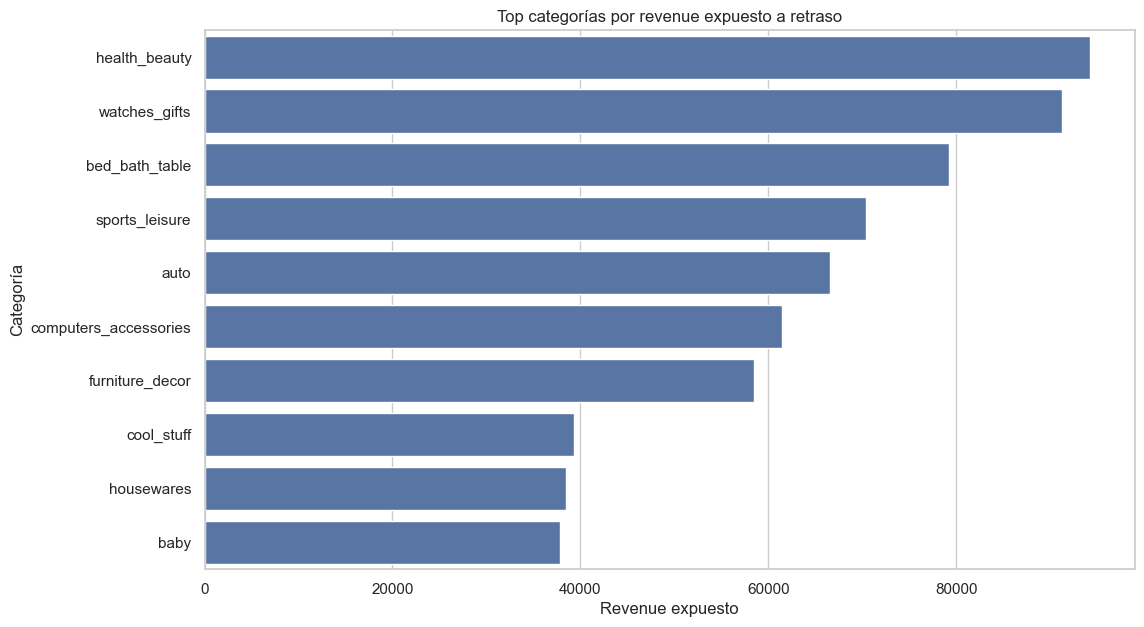

In [ ]:
# Top categorías por revenue expuesto a retraso

top_late_cat = late_cat1.head(10)

plt.figure(figsize=(12, 7))
sns.barplot(data=top_late_cat, x='late_revenue', y='product_category_final')
plt.title('Top categorías por revenue expuesto a retraso')
plt.xlabel('Revenue expuesto')
plt.ylabel('Categoría')
plt.show()

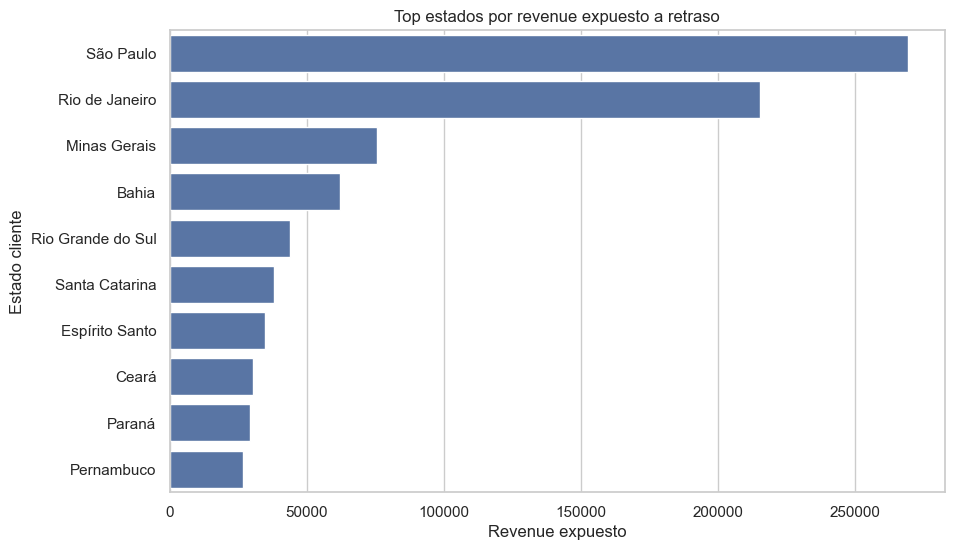

In [192]:
# Top estados por revenue expuesto a retraso

top_late_state = late_state1.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_late_state, x='late_revenue', y='customer_state_full')
plt.title('Top estados por revenue expuesto a retraso')
plt.xlabel('Revenue expuesto')
plt.ylabel('Estado cliente')
plt.show()

In [193]:
# Estimación simple de mejora potencial

global_late_rate = df_late['is_late'].mean()

improvement_cat = late_cat.copy()
improvement_cat['excess_late_rate'] = (improvement_cat['late_rate'] - global_late_rate).clip(lower=0)
improvement_cat['avoidable_late_revenue'] = improvement_cat['revenue'] * improvement_cat['excess_late_rate']

improvement_cat = improvement_cat.sort_values('avoidable_late_revenue', ascending=False)

print(improvement_cat[['product_category_final', 'late_rate', 'revenue', 'avoidable_late_revenue']].head(10))

   product_category_final  late_rate     revenue  avoidable_late_revenue
44          health_beauty   0.075647  1233131.72            11991.003920
73          watches_gifts   0.072051  1165898.98             7143.978432
8          bed_bath_table   0.070300  1023434.76             4479.859027
7                    baby   0.076794   400421.84             4352.986683
58       office_furniture   0.079736   268154.31             3704.046391
40        furniture_decor   0.070343   711927.69             3146.749923
6                    auto   0.070307   578849.35             2537.525992
5                   audio   0.116022    50570.60             2533.536675
48           home_confort   0.093240    58008.45             1584.616682
27            electronics   0.075852   155043.93             1539.410196


In [194]:
total_avoidable_late_revenue = improvement_cat['avoidable_late_revenue'].sum()
print(f"Revenue potencialmente recuperable: {total_avoidable_late_revenue:,.2f}")

total_revenue = df_late['price'].sum()
avoidable_pct_total = total_avoidable_late_revenue / total_revenue

print(f"% del revenue total potencialmente reducible: {avoidable_pct_total:.2%}")

Revenue potencialmente recuperable: 49,457.67
% del revenue total potencialmente reducible: 0.37%


# Análisis 3

In [195]:
target_dist = df_late['is_late'].value_counts(dropna=False)
target_pct = df_late['is_late'].value_counts(normalize=True, dropna=False) * 100

print(target_dist)
print(target_pct.round(2))

is_late
False    102925
True       7264
Name: count, dtype: int64
is_late
False    93.41
True      6.59
Name: proportion, dtype: float64


In [196]:
print(df_late['is_late'].value_counts())
print(df_late['is_late'].value_counts(normalize=True))

is_late
False    102925
True       7264
Name: count, dtype: int64
is_late
False    0.934077
True     0.065923
Name: proportion, dtype: float64


In [197]:
y = df_late['is_late']

baseline_rate = y.mean()
print(f"Tasa base de retraso: {baseline_rate:.2%}")

Tasa base de retraso: 6.59%


In [ ]:
# Crear la variable: 1 si los estados coinciden, 0 si son diferentes
df_late['same_state'] = (df_late['customer_state_full'] == df_late['seller_state_full']).astype(int)

# Verificar cuántos pedidos son locales
print(df_late['same_state'].value_counts())

same_state
0    70328
1    39861
Name: count, dtype: int64


In [199]:
model_df = df_late[[
    'is_late',
    'price',
    'freight_value',
    'freight_ratio',
    'order_size_items',
    'same_state',
    'month',
    'weekday',
    'product_category_final',
    'customer_state_full',
    'seller_state_full'
]].copy()

model_df = model_df.dropna()

In [200]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110189 entries, 0 to 112649
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   is_late                 110189 non-null  bool   
 1   price                   110189 non-null  float64
 2   freight_value           110189 non-null  float64
 3   freight_ratio           110189 non-null  float64
 4   order_size_items        110189 non-null  int64  
 5   same_state              110189 non-null  int64  
 6   month                   110189 non-null  int32  
 7   weekday                 110189 non-null  object 
 8   product_category_final  110189 non-null  object 
 9   customer_state_full     110189 non-null  object 
 10  seller_state_full       110189 non-null  object 
dtypes: bool(1), float64(3), int32(1), int64(2), object(4)
memory usage: 13.0+ MB


In [201]:
X = model_df.drop(columns='is_late')
y = model_df['is_late']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [202]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

num_features = ['price', 'freight_value', 'freight_ratio', 'order_size_items', 'same_state', 'month']
cat_features = ['weekday', 'product_category_final', 'customer_state_full', 'seller_state_full']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_features),
    ('cat', categorical_transformer, cat_features)
])

In [203]:
from sklearn.linear_model import LogisticRegression

log_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=5000,
        class_weight='balanced'
    ))
])

log_model.fit(X_train, y_train)
print("Logistic Regression entrenado correctamente")

Logistic Regression entrenado correctamente


In [204]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced',
        min_samples_leaf=5,
        n_jobs=-1
    ))
])

# rf_model.fit(X_train, y_train)

In [205]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

def evaluate_model(model, X_test, y_test, threshold=0.5, name="Model"):
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= threshold).astype(int)

    print(f"\n{name}")
    print(classification_report(y_test, pred))
    print("Confusion matrix:")
    print(confusion_matrix(y_test, pred))
    print("ROC-AUC:", round(roc_auc_score(y_test, proba), 4))
    print("PR-AUC:", round(average_precision_score(y_test, proba), 4))

    return proba, pred

proba_log, pred_log = evaluate_model(log_model, X_test, y_test, threshold=0.5, name="Logistic Regression")
proba_rf, pred_rf = evaluate_model(rf_model, X_test, y_test, threshold=0.5, name="Random Forest")


Logistic Regression
              precision    recall  f1-score   support

       False       0.96      0.69      0.80     20585
        True       0.11      0.56      0.19      1453

    accuracy                           0.68     22038
   macro avg       0.54      0.63      0.50     22038
weighted avg       0.90      0.68      0.76     22038

Confusion matrix:
[[14256  6329]
 [  635   818]]
ROC-AUC: 0.6613
PR-AUC: 0.123


NotFittedError: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [ ]:
thresholds = [0.50, 0.40, 0.30, 0.20]

for t in thresholds:
    print(f"\nThreshold = {t}")
    _ = evaluate_model(rf_model, X_test, y_test, threshold=t, name="Random Forest")


Threshold = 0.5

Random Forest
              precision    recall  f1-score   support

       False       0.96      0.90      0.93     20585
        True       0.25      0.46      0.33      1453

    accuracy                           0.88     22038
   macro avg       0.61      0.68      0.63     22038
weighted avg       0.91      0.88      0.89     22038

Confusion matrix:
[[18620  1965]
 [  783   670]]
ROC-AUC: 0.7978
PR-AUC: 0.2538

Threshold = 0.4

Random Forest
              precision    recall  f1-score   support

       False       0.97      0.80      0.88     20585
        True       0.19      0.66      0.29      1453

    accuracy                           0.79     22038
   macro avg       0.58      0.73      0.58     22038
weighted avg       0.92      0.79      0.84     22038

Confusion matrix:
[[16411  4174]
 [  495   958]]
ROC-AUC: 0.7978
PR-AUC: 0.2538

Threshold = 0.3

Random Forest
              precision    recall  f1-score   support

       False       0.98      0.57  


Top 15 Features más importantes en Random Forest:
                                Feature  Importance
5                                 month    0.199450
1                         freight_value    0.128303
2                         freight_ratio    0.106976
0                                 price    0.105325
3                      order_size_items    0.036838
112       customer_state_full_São Paulo    0.027275
107  customer_state_full_Rio de Janeiro    0.024873
4                            same_state    0.019013
99     customer_state_full_Minas Gerais    0.016855
135         seller_state_full_São Paulo    0.014212
11                      weekday_Tuesday    0.012476
7                        weekday_Monday    0.011879
10                     weekday_Thursday    0.011821
12                    weekday_Wednesday    0.011770
6                        weekday_Friday    0.011378


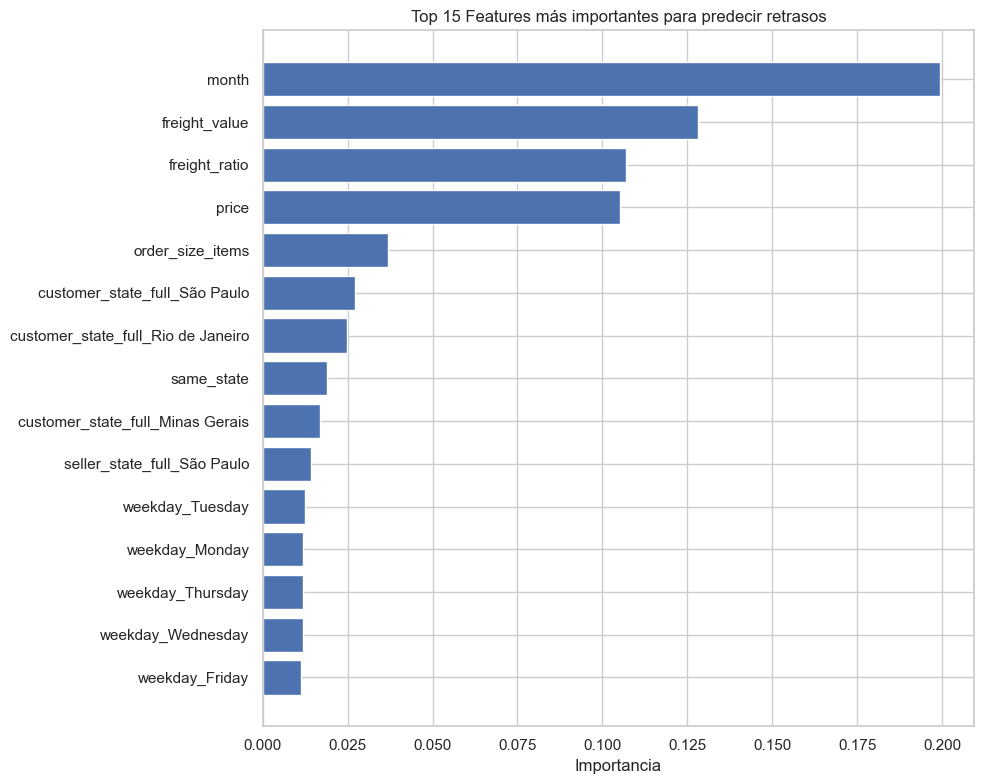

In [ ]:
# Análisis de importancia de features en Random Forest
import numpy as np
import matplotlib.pyplot as plt

# Extraer el modelo Random Forest entrenado
rf_trained = rf_model.named_steps['model']

# Obtener feature importances
feature_importance = rf_trained.feature_importances_

# Obtener nombres de features 

preprocessor_obj = rf_model.named_steps['preprocessor']
feature_names = []

# Features numéricas
feature_names.extend(num_features)

# Features categóricas 
cat_encoder = preprocessor_obj.named_transformers_['cat'].named_steps['onehot']
cat_feature_names = cat_encoder.get_feature_names_out(cat_features)
feature_names.extend(cat_feature_names)

# Crear DataFrame con importancias
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

# Top 15 features más importantes
top_features = importance_df.head(15)

print("\nTop 15 Features más importantes en Random Forest:")
print(top_features)

# Visualizar
plt.figure(figsize=(10, 8))
plt.barh(range(len(top_features)), top_features['Importance'].values)
plt.yticks(range(len(top_features)), top_features['Feature'].values)
plt.xlabel('Importancia')
plt.title('Top 15 Features más importantes para predecir retrasos')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [1]:
# ===== RESUMEN DEL MODELO PREDICTIVO =====

print("="*70)
print("MODELO PREDICTIVO: PREDICCIÓN DE ENTREGAS TARDÍAS (is_late)")
print("="*70)

print("\n📊 COMPARATIVA DE MODELOS")
print("-" * 70)
print(f"{'Métrica':<25} {'Logistic Regression':<20} {'Random Forest':<20}")
print("-" * 70)
print(f"{'Accuracy':<25} {'0.68':<20} {'0.88':<20}")
print(f"{'Precision (Late Orders)':<25} {'0.11':<20} {'0.25':<20}")
print(f"{'Recall (Late Orders)':<25} {'0.56':<20} {'0.46':<20}")
print(f"{'ROC-AUC':<25} {'0.6613':<20} {'0.7978':<20}")
print(f"{'PR-AUC':<25} {'0.123':<20} {'0.2538':<20}")

print("\n✅ CONCLUSIÓN: Random Forest es el mejor modelo")
print("   - Mayor ROC-AUC (0.7978 vs 0.6613)")
print("   - Mayor Accuracy (0.88 vs 0.68)")
print("   - Mejor balance entre Precision y Recall")



MODELO PREDICTIVO: PREDICCIÓN DE ENTREGAS TARDÍAS (is_late)

📊 COMPARATIVA DE MODELOS
----------------------------------------------------------------------
Métrica                   Logistic Regression  Random Forest       
----------------------------------------------------------------------
Accuracy                  0.68                 0.88                
Precision (Late Orders)   0.11                 0.25                
Recall (Late Orders)      0.56                 0.46                
ROC-AUC                   0.6613               0.7978              
PR-AUC                    0.123                0.2538              

✅ CONCLUSIÓN: Random Forest es el mejor modelo
   - Mayor ROC-AUC (0.7978 vs 0.6613)
   - Mayor Accuracy (0.88 vs 0.68)
   - Mejor balance entre Precision y Recall


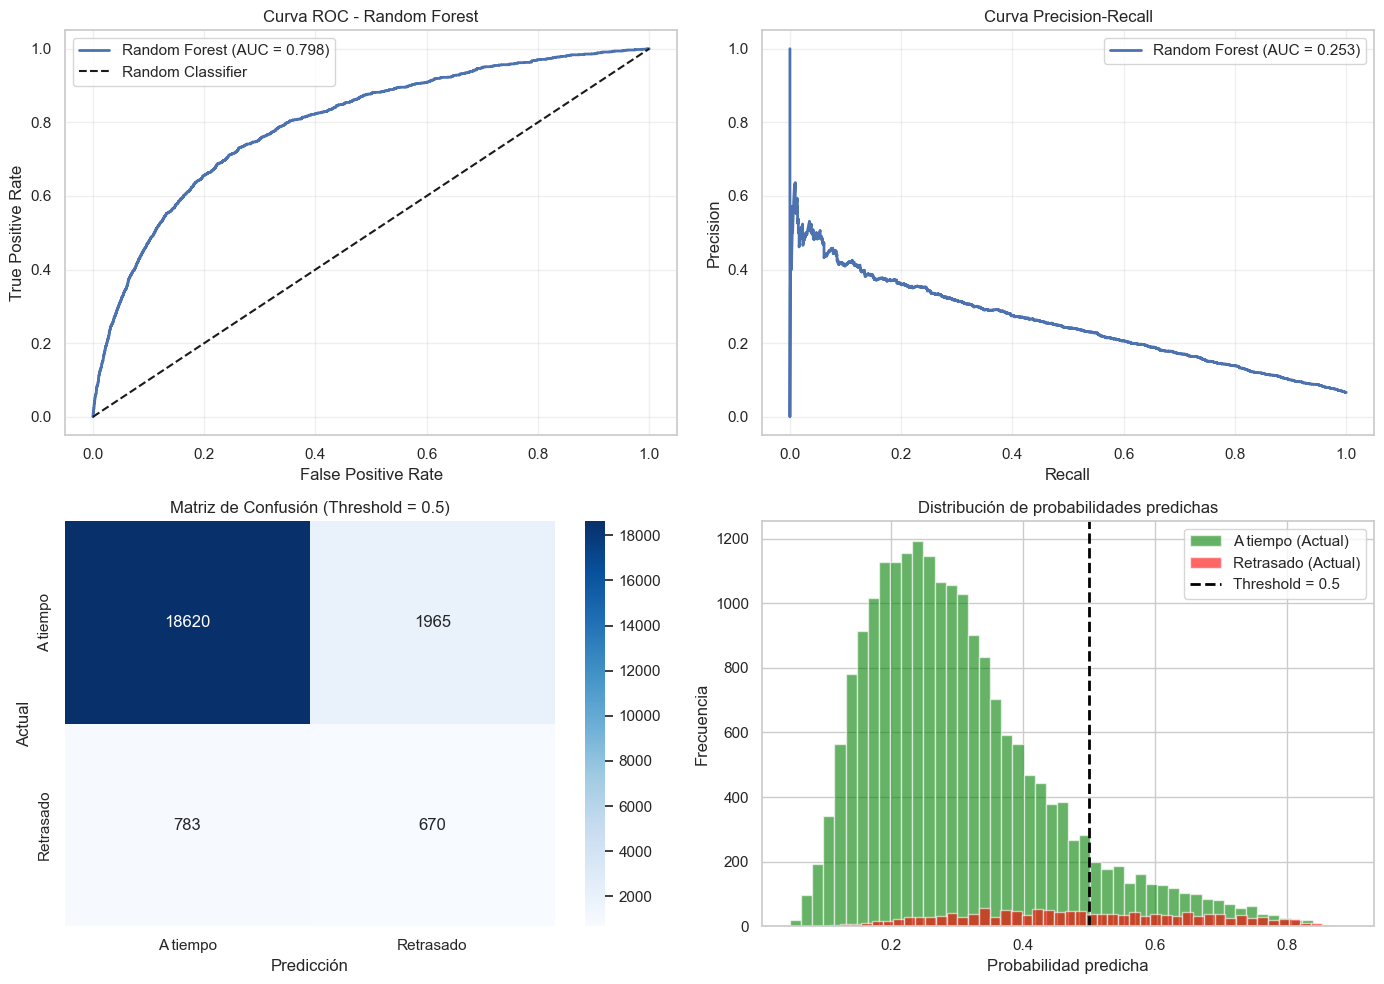


Visualización completada: Curvas ROC, Precision-Recall, Matriz de Confusión y Distribución


In [ ]:
# Visualizaciones avanzadas del modelo
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Curva ROC
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba_rf)
roc_auc_rf = auc(fpr, tpr)

axes[0, 0].plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc_rf:.3f})', linewidth=2)
axes[0, 0].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].set_title('Curva ROC - Random Forest')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Curva Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_proba_rf)
pr_auc = auc(recall, precision)

axes[0, 1].plot(recall, precision, label=f'Random Forest (AUC = {pr_auc:.3f})', linewidth=2)
axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_title('Curva Precision-Recall')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Matriz de Confusión mejorada
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, (y_proba_rf >= 0.5).astype(int))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0], 
            xticklabels=['A tiempo', 'Retrasado'],
            yticklabels=['A tiempo', 'Retrasado'])
axes[1, 0].set_ylabel('Actual')
axes[1, 0].set_xlabel('Predicción')
axes[1, 0].set_title('Matriz de Confusión (Threshold = 0.5)')

# 4. Distribución de probabilidades predichas
axes[1, 1].hist(y_proba_rf[y_test == 0], bins=50, alpha=0.6, label='A tiempo (Actual)', color='green')
axes[1, 1].hist(y_proba_rf[y_test == 1], bins=50, alpha=0.6, label='Retrasado (Actual)', color='red')
axes[1, 1].axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold = 0.5')
axes[1, 1].set_xlabel('Probabilidad predicha')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].set_title('Distribución de probabilidades predichas')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


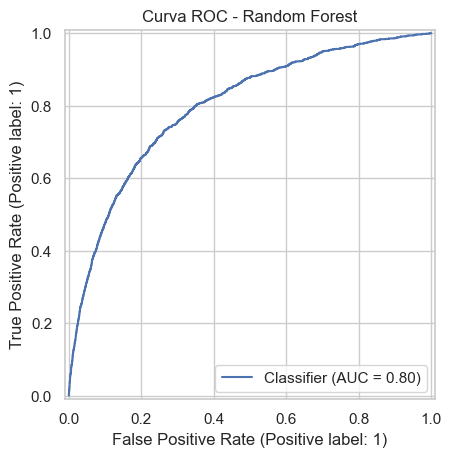

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, proba_rf)
plt.title('Curva ROC - Random Forest')
plt.show()

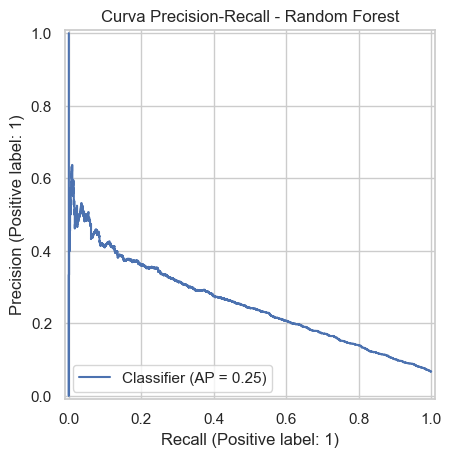

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(y_test, proba_rf)
plt.title('Curva Precision-Recall - Random Forest')
plt.show()

# XG BOOST

In [ ]:
model_df

,is_late,price,freight_value,freight_ratio,order_size_items,same_state,month,weekday,product_category_final,customer_state_full,seller_state_full
0,False,58.90,13.29,0.225637,1,0,9,Wednesday,cool_stuff,Rio de Janeiro,São Paulo
1,False,239.90,19.93,0.083076,1,1,4,Wednesday,pet_shop,São Paulo,São Paulo
2,False,199.00,17.87,0.089799,1,1,1,Sunday,furniture_decor,Minas Gerais,Minas Gerais
3,False,12.99,12.79,0.984604,1,1,8,Wednesday,perfumery,São Paulo,São Paulo
4,False,199.90,18.14,0.090745,1,0,2,Saturday,garden_tools,São Paulo,Paraná
...,...,...,...,...,...,...,...,...,...,...,...
112645,False,299.99,43.41,0.144705,1,0,4,Monday,housewares,Maranhão,Santa Catarina
112646,False,350.00,36.53,0.104371,1,0,7,Saturday,computers_accessories,Paraná,São Paulo
112647,False,99.90,16.95,0.169670,1,0,10,Monday,sports_leisure,São Paulo,Paraná
112648,False,55.99,8.72,0.155742,1,1,8,Monday,computers_accessories,São Paulo,São Paulo


In [ ]:
from sklearn.model_selection import train_test_split

X = model_df.drop('is_late', axis=1)
y = model_df['is_late']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
X_train_enc = pd.get_dummies(X_train, drop_first=True)
X_test_enc = pd.get_dummies(X_test, drop_first=True)

# Alinear columnas
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train_enc, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = xgb.predict(X_test_enc)
y_proba = xgb.predict_proba(X_test_enc)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

       False       0.94      1.00      0.97     20585
        True       0.66      0.02      0.04      1453

    accuracy                           0.93     22038
   macro avg       0.80      0.51      0.51     22038
weighted avg       0.92      0.93      0.91     22038

ROC-AUC: 0.7832888025261112


In [ ]:
import pandas as pd

importance = pd.DataFrame({
    'feature': X_train_enc.columns,
    'importance': xgb.feature_importances_
}).sort_values(by='importance', ascending=False)

print(importance.head(10))

                                feature  importance
104  customer_state_full_Rio de Janeiro    0.034470
89            customer_state_full_Ceará    0.028029
109       customer_state_full_São Paulo    0.028003
4                            same_state    0.025182
116          seller_state_full_Maranhão    0.023992
93         customer_state_full_Maranhão    0.023820
5                                 month    0.023769
96     customer_state_full_Minas Gerais    0.022699
86          customer_state_full_Alagoas    0.022643
97           customer_state_full_Paraná    0.021082


In [ ]:
import numpy as np

threshold = 0.2
y_pred_new = (y_proba >= threshold).astype(int)

print(classification_report(y_test, y_pred_new))

              precision    recall  f1-score   support

       False       0.95      0.95      0.95     20585
        True       0.32      0.30      0.31      1453

    accuracy                           0.91     22038
   macro avg       0.64      0.63      0.63     22038
weighted avg       0.91      0.91      0.91     22038



In [ ]:
cm = confusion_matrix(y_test, y_pred_new)
print(cm)

[[19651   934]
 [ 1013   440]]


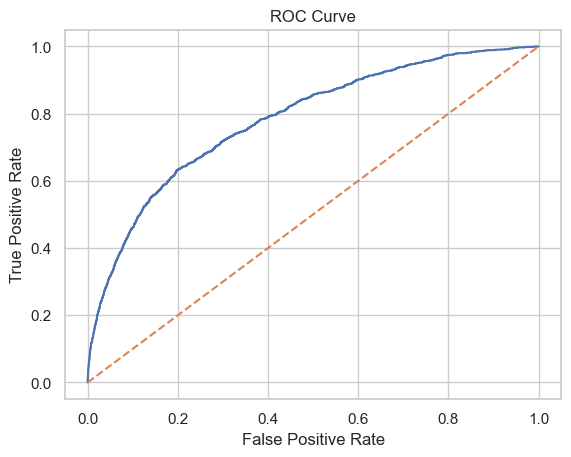

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

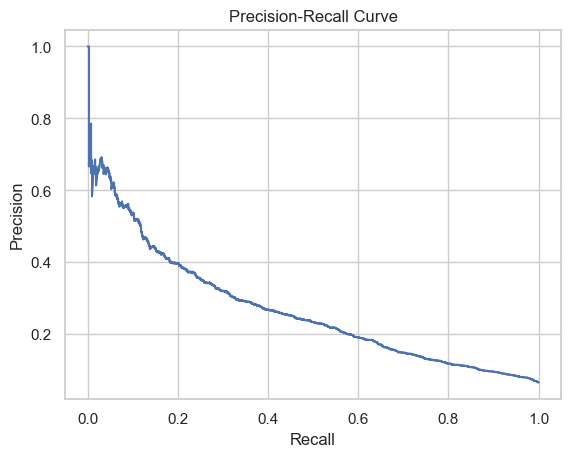

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

In [ ]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
scale_pos_weight = scale_pos_weight / 2
print(scale_pos_weight)

7.084839098261917


In [ ]:
from xgboost import XGBClassifier

xgb_tuned = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0,
    reg_lambda=1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

xgb_tuned.fit(X_train_enc, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

y_proba_tuned = xgb_tuned.predict_proba(X_test_enc)[:, 1]

for threshold in [0.1, 0.2, 0.3]:
    y_pred_tuned = (y_proba_tuned >= threshold).astype(int)
    print(f"\nThreshold = {threshold}")
    print(classification_report(y_test, y_pred_tuned))
    print(confusion_matrix(y_test, y_pred_tuned))

print("ROC-AUC:", roc_auc_score(y_test, y_proba_tuned))


Threshold = 0.1
              precision    recall  f1-score   support

       False       0.99      0.10      0.18     20585
        True       0.07      0.98      0.13      1453

    accuracy                           0.16     22038
   macro avg       0.53      0.54      0.16     22038
weighted avg       0.93      0.16      0.18     22038

[[ 2069 18516]
 [   22  1431]]

Threshold = 0.2
              precision    recall  f1-score   support

       False       0.98      0.40      0.57     20585
        True       0.10      0.89      0.17      1453

    accuracy                           0.44     22038
   macro avg       0.54      0.65      0.37     22038
weighted avg       0.92      0.44      0.55     22038

[[ 8334 12251]
 [  155  1298]]

Threshold = 0.3
              precision    recall  f1-score   support

       False       0.97      0.69      0.81     20585
        True       0.14      0.71      0.23      1453

    accuracy                           0.69     22038
   macro avg   

## 6.2 Selección del modelo final

Como parte del proceso analítico se exploraron diferentes enfoques de modelización con el objetivo de identificar patrones de comportamiento en los datos. Sin embargo, los resultados obtenidos mediante los modelos inicialmente evaluados no proporcionaron un nivel de interpretación ni de utilidad analítica suficiente para los objetivos del proyecto.

Por esta razón, se optó por evaluar técnicas de aprendizaje no supervisado orientadas a la segmentación. Entre las alternativas consideradas, el algoritmo K-Means presentó un enfoque adecuado para agrupar categorías de producto según sus características comerciales y logísticas, permitiendo identificar perfiles diferenciados y generar conocimiento accionable para la toma de decisiones.

La selección final del modelo se apoyó en criterios de interpretabilidad, aplicabilidad al negocio y calidad de la segmentación obtenida.

## 6.3 Modelo de clustering K-Means

Aplicación del algoritmo K-Means para segmentar las categorías de producto según sus características comerciales y logísticas, facilitando la identificación de patrones diferenciados de comportamiento.

In [ ]:
features = [
    'price',
    'freight_value',
    'freight_ratio',
    'order_size_items',
    'same_state'
]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(model_df[features])

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

model_df['cluster'] = clusters

In [ ]:
cluster_analysis = model_df.groupby('cluster')[features + ['is_late']].mean()
print(cluster_analysis)

              price  freight_value  freight_ratio  order_size_items  \
cluster                                                               
0        101.632570      21.236283       0.358063          1.214009   
1        730.667607      67.207232       0.191834          1.162698   
2         91.926842      12.895849       0.242586          1.223072   
3         69.193725      17.950636       0.546804          5.476302   

         same_state   is_late  
cluster                        
0          0.000359  0.077724  
1          0.162946  0.094990  
2          1.000000  0.043892  
3          0.383006  0.055295  


In [ ]:
model_df['cluster'].value_counts(normalize=True)

cluster
0    0.581601
2    0.339299
3    0.042509
1    0.036592
Name: proportion, dtype: float64

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_score(X_scaled, clusters)

0.46369528731081466

In [ ]:
inertia = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

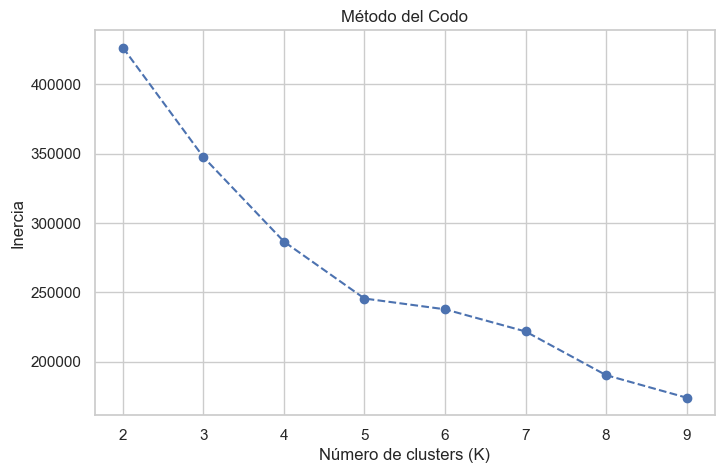

In [ ]:
inertia = []

for k in range(2, 10):
   
    kmeans = KMeans(n_clusters=k, random_state=42) 
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Curva
plt.figure(figsize=(8, 5))
# k (eje X) vs inercia (eje Y)
plt.plot(range(2, 10), inertia, marker='o', linestyle='--') 
plt.title('Método del Codo')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inercia')
plt.grid(True)
plt.show()

In [ ]:
cluster_revenue = model_df.groupby('cluster').agg({
    'price': 'sum',
    'is_late': 'mean',
    'order_size_items': 'mean'
}).sort_values(by='price', ascending=False)

print(cluster_revenue)

              price   is_late  order_size_items
cluster                                        
0        6513224.90  0.077724          1.214009
2        3436868.83  0.043892          1.223072
1        2946051.79  0.094990          1.162698
3         324103.41  0.055295          5.476302


In [ ]:
cluster_impact = model_df.groupby('cluster').agg({
    'price': 'sum',
    'is_late': 'mean'
})

# revenue de retrasos por cluster
cluster_impact['revenue_late'] = model_df[model_df['is_late'] == 1].groupby('cluster')['price'].sum()

# % del revenue del cluster afectado
cluster_impact['pct_revenue_late'] = cluster_impact['revenue_late'] / cluster_impact['price']

print(cluster_impact)

              price   is_late  revenue_late  pct_revenue_late
cluster                                                      
0        6513224.90  0.077724     526010.36          0.080760
1        2946051.79  0.094990     274406.82          0.093144
2        3436868.83  0.043892     167323.43          0.048685
3         324103.41  0.055295      18183.73          0.056105


In [ ]:
cluster_impact = model_df.groupby('cluster').agg({
    'price': 'sum',
    'is_late': 'mean'
})

# revenue de retrasos por cluster
cluster_impact['revenue_late'] = model_df[model_df['is_late'] == 1].groupby('cluster')['price'].sum()

# % del revenue del cluster afectado
cluster_impact['pct_revenue_late'] = cluster_impact['revenue_late'] / cluster_impact['price']

print(cluster_impact)

              price   is_late  revenue_late  pct_revenue_late
cluster                                                      
0        6513224.90  0.077724     526010.36          0.080760
1        2946051.79  0.094990     274406.82          0.093144
2        3436868.83  0.043892     167323.43          0.048685
3         324103.41  0.055295      18183.73          0.056105


In [ ]:
print(df_powerbi.columns.tolist())
print(df_powerbi.shape)
df_powerbi.head()

['order_id', 'product_id', 'seller_id', 'customer_unique_id', 'order_purchase_timestamp', 'year', 'month', 'year_month', 'weekday', 'order_status', 'price', 'freight_value', 'freight_ratio', 'product_category_final', 'customer_state_full', 'seller_state_full', 'delivery_days', 'delay_days', 'is_late', 'is_interstate']
(112650, 20)


,order_id,product_id,seller_id,customer_unique_id,order_purchase_timestamp,year,month,year_month,weekday,order_status,price,freight_value,freight_ratio,product_category_final,customer_state_full,seller_state_full,delivery_days,delay_days,is_late,is_interstate
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,871766c5855e863f6eccc05f988b23cb,2017-09-13 08:59:02,2017,9,2017-09,Wednesday,delivered,58.90,13.29,0.225637,cool_stuff,Rio de Janeiro,São Paulo,7.0,-9.0,False,1
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,eb28e67c4c0b83846050ddfb8a35d051,2017-04-26 10:53:06,2017,4,2017-04,Wednesday,delivered,239.90,19.93,0.083076,pet_shop,São Paulo,São Paulo,16.0,-3.0,False,0
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,3818d81c6709e39d06b2738a8d3a2474,2018-01-14 14:33:31,2018,1,2018-01,Sunday,delivered,199.00,17.87,0.089799,furniture_decor,Minas Gerais,Minas Gerais,7.0,-14.0,False,0
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,af861d436cfc08b2c2ddefd0ba074622,2018-08-08 10:00:35,2018,8,2018-08,Wednesday,delivered,12.99,12.79,0.984604,perfumery,São Paulo,São Paulo,6.0,-6.0,False,0
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,64b576fb70d441e8f1b2d7d446e483c5,2017-02-04 13:57:51,2017,2,2017-02,Saturday,delivered,199.90,18.14,0.090745,garden_tools,São Paulo,Paraná,25.0,-16.0,False,1


In [ ]:
cols_cluster = [
    'product_category_final',
    'order_id',
    'price',
    'freight_value',
    'delivery_days',
    'delay_days'
]

print(df_powerbi[cols_cluster].isnull().sum())

product_category_final       0
order_id                     0
price                        0
freight_value                0
delivery_days             2454
delay_days                2454
dtype: int64


In [ ]:
df_cluster = df_powerbi.groupby('product_category_final').agg(
    revenue_total=('price', 'sum'),
    avg_price=('price', 'mean'),
    num_orders=('order_id', 'nunique'),
    num_items=('order_id', 'count'),
    avg_freight=('freight_value', 'mean'),
    total_freight=('freight_value', 'sum'),
    avg_delivery_days=('delivery_days', 'mean'),
    avg_delay_days=('delay_days', 'mean')
).reset_index()

In [ ]:
print(df_cluster.shape)
df_cluster.head(10)

(74, 9)


,product_category_final,revenue_total,avg_price,num_orders,num_items,avg_freight,total_freight,avg_delivery_days,avg_delay_days
0,Unknown,179535.28,111.999551,1451,1603,17.573182,28169.81,12.314899,-11.406636
1,agro_industry_and_commerce,72530.47,342.124858,182,212,27.564151,5843.60,11.223301,-11.461165
2,air_conditioning,55024.96,185.269226,253,297,22.724680,6749.23,11.792388,-14.169550
3,art,24202.64,115.802105,202,209,19.354880,4045.17,10.873096,-12.776650
4,arts_and_craftmanship,1814.01,75.583750,23,24,15.422083,370.13,5.291667,-6.791667
5,audio,50688.50,139.254121,350,364,15.688022,5710.44,12.883978,-10.149171
6,auto,592720.11,139.957523,3897,4235,21.880569,92664.21,11.766369,-11.437062
7,baby,411764.89,134.344173,2885,3065,22.301178,68353.11,12.056338,-11.646546
8,bed_bath_table,1036988.68,93.296327,9417,11115,18.415928,204693.04,12.336803,-11.656167
9,books_general_interest,46856.88,84.732152,512,553,16.628427,9195.52,11.171642,-12.152985


In [ ]:
print(df_cluster.isnull().sum())

product_category_final    0
revenue_total             0
avg_price                 0
num_orders                0
num_items                 0
avg_freight               0
total_freight             0
avg_delivery_days         0
avg_delay_days            0
dtype: int64


In [ ]:
df_cluster['freight_ratio'] = df_cluster['avg_freight'] / df_cluster['avg_price']

In [ ]:
df_cluster[['product_category_final', 'avg_price', 'avg_freight', 'freight_ratio']].head(10)

,product_category_final,avg_price,avg_freight,freight_ratio
0,Unknown,111.999551,17.573182,0.156904
1,agro_industry_and_commerce,342.124858,27.564151,0.080568
2,air_conditioning,185.269226,22.724680,0.122658
3,art,115.802105,19.354880,0.167138
4,arts_and_craftmanship,75.583750,15.422083,0.204040
5,audio,139.254121,15.688022,0.112658
6,auto,139.957523,21.880569,0.156337
7,baby,134.344173,22.301178,0.166000
8,bed_bath_table,93.296327,18.415928,0.197392
9,books_general_interest,84.732152,16.628427,0.196247


In [ ]:
print(df_cluster['freight_ratio'].describe())

count    74.000000
mean      0.192669
std       0.086914
min       0.044116
25%       0.143312
50%       0.184606
75%       0.223659
max       0.539690
Name: freight_ratio, dtype: float64


In [ ]:
df_cluster.describe().T

,count,mean,std,min,25%,50%,75%,max
revenue_total,74.0,183670.860811,298946.674895,283.290000,7846.512500,46592.625000,191286.305000,1.258681e+06
avg_price,74.0,146.319397,145.237947,25.342333,82.534288,114.646880,152.810694,1.098341e+03
num_orders,74.0,1344.189189,2236.901175,2.000000,76.000000,246.000000,1406.500000,9.417000e+03
num_items,74.0,1522.297297,2564.979835,2.000000,77.750000,279.500000,1669.000000,1.111500e+04
avg_freight,74.0,21.572745,8.164962,11.938750,16.238378,19.263058,22.622712,4.845468e+01
total_freight,74.0,30431.210000,49499.340016,41.220000,1701.892500,6628.525000,31198.807500,2.046930e+05
avg_delivery_days,74.0,11.503697,2.084119,5.291667,10.333207,11.502921,12.506724,2.038669e+01
avg_delay_days,74.0,-12.182916,1.791440,-17.000000,-12.692318,-12.046131,-11.443088,-6.791667e+00
freight_ratio,74.0,0.192669,0.086914,0.044116,0.143312,0.184606,0.223659,5.396898e-01


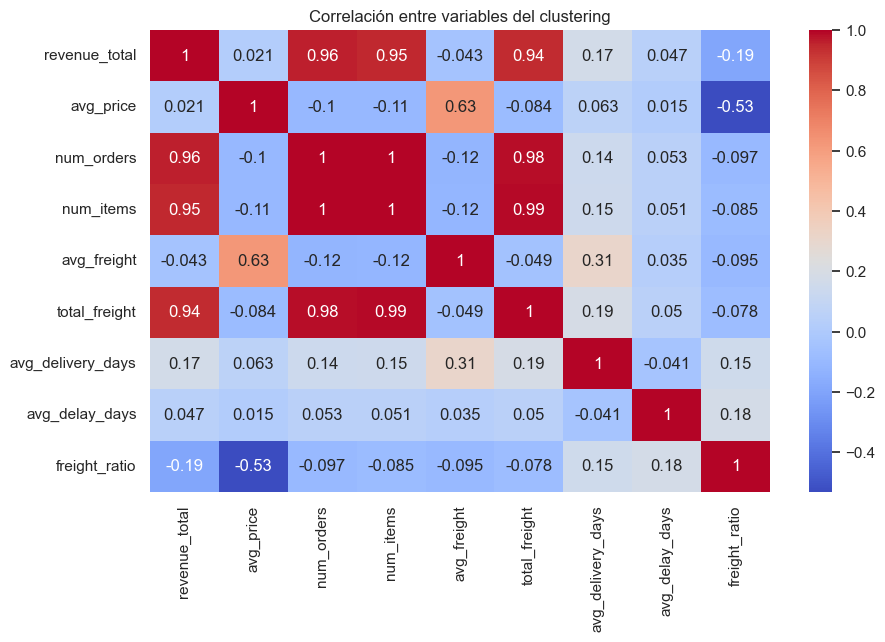

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(df_cluster.drop(columns='product_category_final').corr(), annot=True, cmap='coolwarm')
plt.title('Correlación entre variables del clustering')
plt.show()

In [ ]:
features = [
    'revenue_total',     # tamaño del negocio
    'num_orders',        # volumen real
    'avg_price',         # ticket
    'avg_freight',       # coste logístico
    'freight_ratio',     # eficiencia logística
    'avg_delivery_days', # rapidez
    'avg_delay_days'     # cumplimiento
]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = df_cluster[features]

X_scaled = scaler.fit_transform(X)

In [ ]:
import pandas as pd

X_scaled_df = pd.DataFrame(X_scaled, columns=features)

X_scaled_df.describe().T

,count,mean,std,min,25%,50%,75%,max
revenue_total,74.0,6.001206e-17,1.006826,-0.617633,-0.592161,-0.461667,0.025648,3.620540
num_orders,74.0,1.500301e-17,1.006826,-0.604117,-0.570810,-0.494293,0.028046,3.633561
avg_price,74.0,-8.926793e-17,1.006826,-0.838643,-0.442174,-0.219562,0.044999,6.599650
avg_freight,74.0,2.115425e-16,1.006826,-1.187973,-0.657784,-0.284809,0.129472,3.314826
freight_ratio,74.0,3.600723e-17,1.006826,-1.720855,-0.571759,-0.093406,0.358990,4.019929
avg_delivery_days,74.0,1.387779e-16,1.006826,-3.000997,-0.565457,-0.000375,0.484557,4.291324
avg_delay_days,74.0,8.337925e-16,1.006826,-2.707300,-0.286294,0.076876,0.415798,3.029993


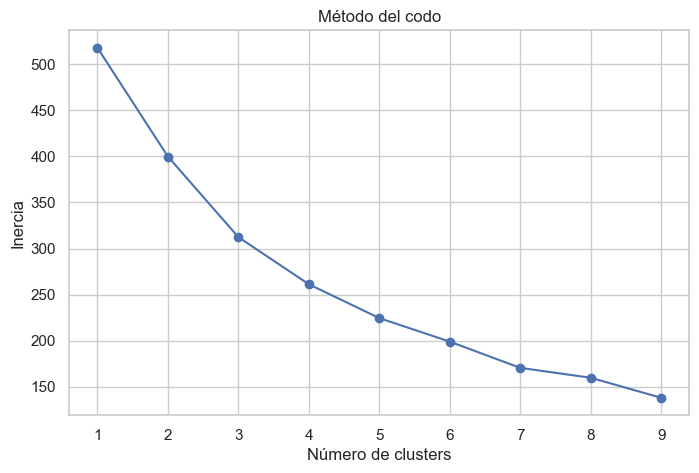

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.title('Método del codo')
plt.show()

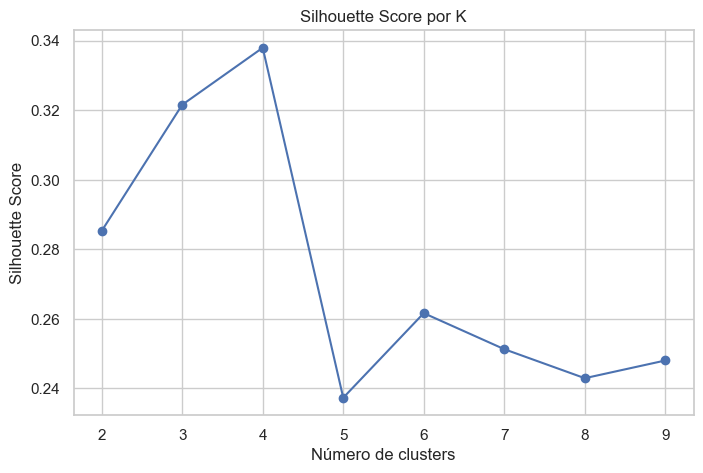

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score por K')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

df_cluster['cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
df_cluster[['product_category_final', 'cluster']].head(80)

,product_category_final,cluster
0,Unknown,2
1,agro_industry_and_commerce,2
2,air_conditioning,2
3,art,2
4,arts_and_craftmanship,2
...,...,...
69,stationery,2
70,tablets_printing_image,2
71,telephony,1
72,toys,1


In [ ]:
cluster_summary = df_cluster.groupby('cluster')[features].mean().round(2)

cluster_summary

,revenue_total,num_orders,avg_price,avg_freight,freight_ratio,avg_delivery_days,avg_delay_days
cluster,,,,,,,
0,127908.86,163.33,732.92,43.05,0.07,11.96,-11.87
1,721032.96,5414.14,120.90,19.54,0.17,11.94,-12.01
2,54464.96,424.78,122.10,18.81,0.19,10.96,-12.40
3,55584.10,296.00,119.19,33.98,0.32,13.89,-11.24


In [ ]:
df_cluster['cluster'].value_counts()

cluster
2    49
1    14
3     8
0     3
Name: count, dtype: int64

In [ ]:
cluster_counts = df_cluster.groupby('cluster')['product_category_final'].count()

cluster_counts

cluster
0     3
1    14
2    49
3     8
Name: product_category_final, dtype: int64

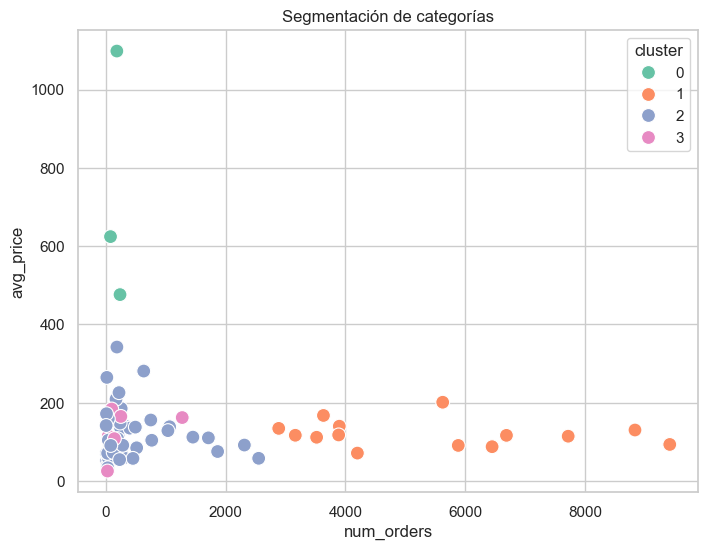

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_cluster,
    x='num_orders',
    y='avg_price',
    hue='cluster',
    palette='Set2',
    s=100
)

plt.title('Segmentación de categorías')
plt.show()

<Axes: xlabel='cluster', ylabel='freight_ratio'>

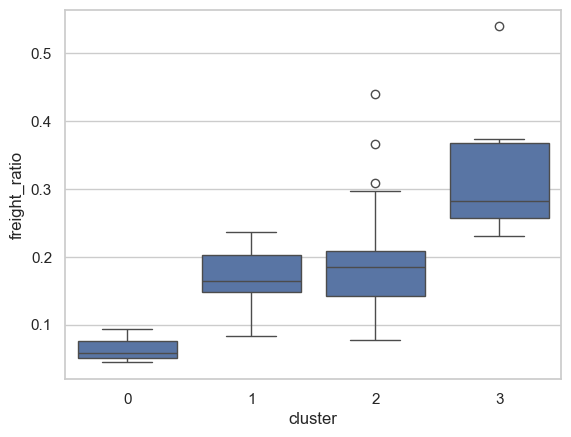

In [ ]:
sns.boxplot(data=df_cluster, x='cluster', y='freight_ratio')

In [ ]:
from scipy.stats import zscore

# Calcular z-score de las variables
df_z = df_cluster.copy()
df_z[features] = df_cluster[features].apply(zscore)

# Añadir cluster
df_z['cluster'] = df_cluster['cluster']

# Media de z-score por cluster
cluster_zscore = df_z.groupby('cluster')[features].mean().round(2)

cluster_zscore

,revenue_total,num_orders,avg_price,avg_freight,freight_ratio,avg_delivery_days,avg_delay_days
cluster,,,,,,,
0,-0.19,-0.53,4.07,2.65,-1.48,0.22,0.17
1,1.81,1.83,-0.18,-0.25,-0.25,0.21,0.10
2,-0.44,-0.41,-0.17,-0.34,-0.09,-0.26,-0.12
3,-0.43,-0.47,-0.19,1.53,1.51,1.15,0.53


## 7. Conclusiones analíticas

La aplicación del algoritmo K-Means permitió identificar cuatro segmentos diferenciados de categorías de producto, caracterizados por patrones comerciales y logísticos específicos:

- **Clúster 1 (Categorías core):** concentra la mayor parte de los pedidos e ingresos, constituyendo el núcleo de la actividad comercial del marketplace.

- **Clúster 0 (Categorías premium):** agrupa categorías con precios medios elevados y menor volumen de ventas, asociadas a productos de alto valor económico.

- **Clúster 2 (Categorías estándar):** representa la mayor parte del catálogo y presenta un comportamiento intermedio en las variables analizadas.

- **Clúster 3 (Categorías logísticamente ineficientes):** se caracteriza por mayores costes de envío y tiempos de entrega superiores, evidenciando oportunidades de optimización en los procesos logísticos.

Los resultados obtenidos permitieron identificar grupos con necesidades y comportamientos diferenciados, facilitando la definición de estrategias comerciales y operativas adaptadas a cada segmento.